# Loan Sanction Amount Estimation

## The problem

Someone applying for a loan asks for a certain figure, and the bank almost never
sanctions exactly that figure. Part of the request is often cut, and a fair
number of applications are refused outright and get nothing. The applicant
usually learns this only at the end of the process, after the paperwork has been
filed and a few weeks have passed.

This notebook estimates that number early. It reads the details an applicant
already knows about themselves, such as income, credit score, existing loan
expenses and the price of the property, and returns the amount that is likely to
be sanctioned. It is not a lending decision and it does not replace the bank's
own checks. It is an early figure so that a person can see roughly where they
stand before committing time to the application.

## Goal

The notebook sets out to produce two things.

1. A model that takes a single application and predicts the sanctioned amount in
   US dollars, together with a prediction of whether anything is sanctioned at
   all.
2. A record of how that number was arrived at: what the raw data actually
   contained, which parts of it turned out to be unusable, what was done about
   them and how the finished model scores on applications it never saw during
   training.

## The data

The data comes from the Kaggle dataset "Predict Loan Amount Data", available at
<https://www.kaggle.com/datasets/phileinsophos/predict-loan-amount-data>. The
file used is `train.csv`, kept in the repository at `src/data/train.csv`.

It holds 30,000 applications in 24 columns, indexed by `Customer ID`. The column
being predicted is `Loan Sanction Amount (USD)`.

678 of those rows have nothing in the target column. A missing target cannot be
filled in with a guess, because the guess would then become the answer the model
is trained to copy. Those rows are dropped and 29,322 remain.

The important detail is inside the remaining rows. 7,865 of them, which is 26.8
percent, have a sanctioned amount of exactly 0. A 0 here is not a very small
loan. It records that the application was refused. So over a quarter of the
target column is not an amount at all, it is a rejection, and any model built on
this data has to deal with that before it can predict anything sensible.

## How the results are judged

The headline number is RMSE, reported in US dollars. The thing being predicted is
a sum of money, so the error should be readable as money too. An error quoted in
dollars tells a reader directly how far off a typical estimate is, which a
unitless score does not. RMSE also penalises the big misses more than the small
ones, which fits the situation, since quoting an applicant a figure that is
wildly wrong does more damage than being a little off.

R2 is reported next to it. RMSE says how far the predictions land from the truth,
and R2 says how much of the spread in the sanctioned amounts the model actually
accounts for. A low RMSE on a target that barely varies is not an achievement,
and R2 is what exposes that.

The approval stage is judged on F1 rather than accuracy. Roughly 73 percent of
applications in this data are approved, so a model that approves everybody and
reads none of the inputs already scores 0.73 accuracy and an F1 of 0.8451. Those
two numbers are recorded here as the bar to clear, because an accuracy just above
0.73 sounds acceptable until it is placed next to the 0.73 that comes for free.
Accuracy on a split this uneven mostly measures the split. F1 is used instead
because it only improves when the model gets the refusals right as well as the
approvals, and the refusals are the reason this stage exists.

## Approach

The target holds two different questions stacked together. Is anything sanctioned
at all, and if yes, how much? A single regressor fitted over the whole column has
to aim at 0 for a quarter of the rows and at a large amount for the rest, so it
settles somewhere in between and serves neither group. It ends up predicting
small positive amounts for people who were refused and pulling the approved
predictions down.

So the work is split into two stages that run one after the other.

- **Stage 1, a classifier.** Predicts whether the application is sanctioned any
  amount at all. Judged on F1, as described above.
- **Stage 2, a regressor.** Trained only on the approved applications, it
  predicts how much is sanctioned. Judged on RMSE and R2.

At prediction time the two are chained. An application that stage 1 marks as
refused is reported as 0 and never reaches the regressor. Only the ones it passes
get an amount.

The refused rows are not deleted from the project, even though stage 2 does not
train on them. They are 26.8 percent of the data and, for those applicants, 0 is
the correct answer. Dropping them would leave a model that has never seen a
rejection, quietly assumes every application succeeds and has no way of saying
no. They are moved to stage 1 instead of being thrown away.

The diagram below traces that path. Its source lives in
`report/diagrams/two_stage.mmd` and is pasted into this cell unchanged, so the
flow shown here and the one rendered into the written report share one file
instead of two that could quietly drift apart.

```mermaid
flowchart LR
    A[All 29,322 applications] --> B{Stage 1<br/>Any amount sanctioned?}
    B -- No --> C[Predict 0]
    B -- Yes --> D[Stage 2<br/>Predict the amount]
    C --> E[End to end score<br/>all test rows]
    D --> E
```

## References

1. **Consumer credit-risk models via machine-learning algorithms.** A. E. Khandani, A. J. Kim, A. W. Lo. *Journal of Banking & Finance*, 2010. <https://www.sciencedirect.com/science/article/abs/pii/S0378426610002372>
2. **Benchmarking state-of-the-art classification algorithms for credit scoring: An update of research.** S. Lessmann, B. Baesens, H.-V. Seow, L. C. Thomas. *European Journal of Operational Research*, 2015. <https://www.sciencedirect.com/science/article/abs/pii/S0377221715004208>
3. **Why do tree-based models still outperform deep learning on typical tabular data?** L. Grinsztajn, E. Oyallon, G. Varoquaux. *Advances in Neural Information Processing Systems (NeurIPS), Datasets and Benchmarks Track*, 2022. <https://arxiv.org/abs/2207.08815>
4. **A Unified Approach to Interpreting Model Predictions.** S. M. Lundberg, Su-In Lee. *Advances in Neural Information Processing Systems (NeurIPS)*, 2017. <https://arxiv.org/abs/1705.07874>
5. **Some Statistical Models for Limited Dependent Variables with Application to the Demand for Durable Goods.** J. G. Cragg. *Econometrica*, 1971. <https://www.econometricsociety.org/publications/econometrica/1971/09/01/some-statistical-models-limited-dependent-variables-application>
6. **Predictably Unequal? The Effects of Machine Learning on Credit Markets.** A. Fuster, P. Goldsmith-Pinkham, T. Ramadorai, A. Walther. *The Journal of Finance*, 2022. <https://onlinelibrary.wiley.com/doi/abs/10.1111/jofi.13090>

## Setup

### Settings used throughout

`RANDOM_STATE` is pinned to 42. Every split, every cross validation fold and
every model that draws random numbers uses it, so rerunning the notebook gives
the same figures as the ones written in the narration below.

`RETRAIN` decides whether the tuning searches are run again or the fitted models
are loaded from `../models`. It is left as `False`, which lets the notebook run
end to end in a few minutes. Setting it to `True` runs the searches from scratch,
which takes considerably longer.

The paths are written relative to `src/`, since that is the directory the
notebook runs from.

Only `FutureWarning` is filtered out, and nothing else. This is deliberate. An
earlier version of this work silenced every warning at the top of the file, and
that filter hid 180 model fits that had failed. The scores being read off the
screen were not the scores the code had produced, and nothing on screen said so.
Warnings that indicate a real problem are left visible.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42
RETRAIN = False
DATA = Path("data/train.csv")
MODELS = Path("../models")
MODELS.mkdir(exist_ok=True)

# Only specific noisy warnings are silenced, never all of them.
# A blanket filter is what hid 180 failed fits in the earlier version of this work.
warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(RANDOM_STATE)

## Loading the data

The raw file is read with `Customer ID` as the index. That column is just a
label for the row, so keeping it as the index stops it from being handed to a
model later on as if it were a feature. This is also why the count printed below
is 23 and not 24. The identifier is still there, it has simply stopped being
counted as a column of data.

In [2]:
df = pd.read_csv(DATA, index_col="Customer ID")
print(f"rows loaded: {len(df):,}   columns: {df.shape[1]}")

rows loaded: 30,000   columns: 23


### The -999 entries and rows with no target

Several columns use `-999` where the value was simply never recorded. Left alone,
a model reads it as a real quantity, so an unrecorded income of -999 dollars gets
averaged in with genuine incomes and drags the column down. Every `-999` is
converted to a proper blank first, and from that point on it is handled like any
other missing value.

The target is treated differently from the features. A missing feature can be
filled in from the rest of the column, but a missing `Loan Sanction Amount (USD)`
cannot, because filling it would mean inventing the answer and then training the
model to reproduce the invention. Those rows are dropped instead.

In [3]:
# -999 is a placeholder for "not recorded", not a real amount
df = df.replace(-999, np.nan)

# The target cannot be imputed, so rows without it are dropped
before = len(df)
df = df.dropna(subset=["Loan Sanction Amount (USD)"])
print(f"dropped {before - len(df):,} rows with no target, {len(df):,} remain")

dropped 678 rows with no target, 29,322 remain


### Columns that carry no information

Three columns go at this point.

`Name` and `Property ID` are identifiers. They are unique or nearly unique per
row, so a model can only memorise them, and memorised labels do not transfer to
an applicant it has not met.

`Property Age` is the interesting one. It is a copy of `Income (USD)`, identical
to the cent in all 25,150 rows where both are present. The evidence for that
claim is printed in the audit block below rather than asserted here. Keeping both
would feed the same numbers to the model twice under two different names, so one
copy is dropped.

In [4]:
# Property Age duplicates Income exactly. Evidence is printed in the audit block below.
df = df.drop(columns=["Name", "Property Age", "Property ID"])
print(f"columns after dropping identifiers and the duplicate: {df.shape[1]}")

columns after dropping identifiers and the duplicate: 20


## Auditing the data

Block 2 already converted every `-999` to `NaN` and dropped the rows with no
target. Before that conversion, `-999` sat inside a numeric column looking like
an ordinary reading, so a null count taken straight off the raw file would have
missed it wherever it was used and reported some columns as more complete than
they are. Only from this point does `isna()` actually see it, so this is the
first place in the notebook where a missing count for each column can be
trusted. The chart is also saved to `report/figures`, since this table is the
reference point for the imputation choices made later in the pipeline block.

Type of Employment             24.30
Income (USD)                   15.04
Dependents                      8.19
Credit Score                    5.60
Income Stability                5.55
Has Active Credit Card          5.19
Property Location               1.16
Property Price                  1.14
Current Loan Expenses (USD)     1.13
Co-Applicant                    0.55
Gender                          0.17
No. of Defaults                 0.00
Property Type                   0.00
Expense Type 2                  0.00
Age                             0.00
Expense Type 1                  0.00
Loan Amount Request (USD)       0.00
Location                        0.00
Profession                      0.00
Loan Sanction Amount (USD)      0.00

entries that were the -999 placeholder before block 2's conversion:
Current Loan Expenses (USD)    177
Co-Applicant                   168
Property Price                 352
Loan Sanction Amount (USD)     338


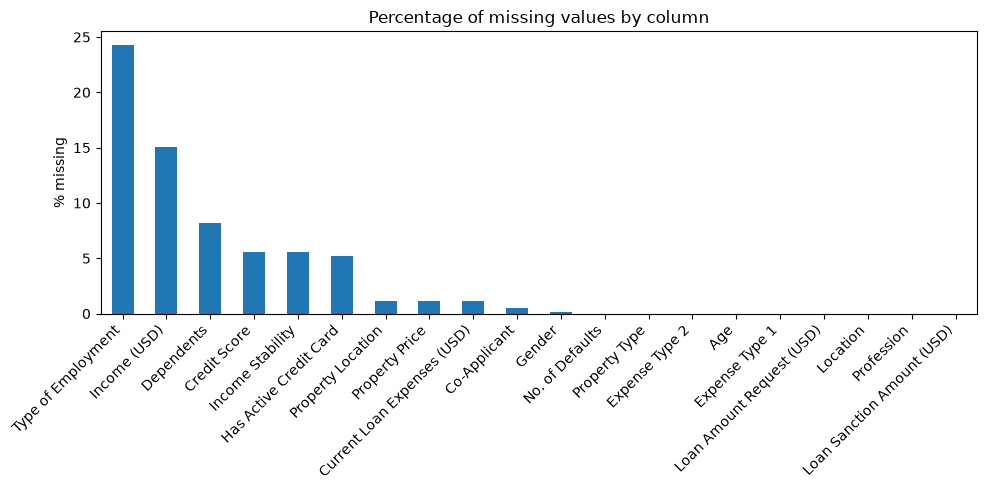

In [5]:
import matplotlib.pyplot as plt

null_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(null_pct.round(2).to_string())

raw_for_sentinel = pd.read_csv(DATA, index_col="Customer ID")
sentinel_counts = (raw_for_sentinel == -999).sum()
sentinel_counts = sentinel_counts[sentinel_counts > 0]
print("\nentries that were the -999 placeholder before block 2's conversion:")
print(sentinel_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
null_pct.plot(kind="bar", ax=ax)
ax.set_title("Percentage of missing values by column")
ax.set_ylabel("% missing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../report/figures/missingness.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

`Type of Employment` is missing in 24.3 percent of rows and `Income (USD)` in
15.0 percent, and both need an imputation strategy rather than a plain drop,
since dropping either would take a fifth or a quarter of the data with it.
Further down the chart, `Property Price`, `Co-Applicant` and `Current Loan
Expenses (USD)` look almost complete, yet 352, 168 and 177 of their entries
respectively were recorded as `-999` rather than left blank. The target column
carried the same placeholder: 338 of the 678 rows dropped in block 2 for having
no target were `-999` in disguise rather than an empty cell.

### Confirming the duplicate column

Stating that `Property Age` duplicates `Income (USD)` is a strong claim, so it
needs to show its own working rather than rest on block 2's word for it. The raw
file is read again here because `Property Age` no longer exists in `df` by this
point, having already been dropped.

In [6]:
raw = pd.read_csv(DATA, index_col="Customer ID").replace(-999, np.nan)
pair = raw[["Income (USD)", "Property Age"]].dropna()
identical = bool((pair["Income (USD)"] == pair["Property Age"]).all())
print(f"rows where both are present : {len(pair):,}")
print(f"identical in every one      : {identical}")
print(f"correlation                 : {pair.corr().iloc[0, 1]:.6f}")
print(pair.head(5).to_string())

rows where both are present : 25,150
identical in every one      : True
correlation                 : 1.000000
             Income (USD)  Property Age
Customer ID                            
C-36995           1933.05       1933.05
C-33999           4952.91       4952.91
C-3770             988.19        988.19
C-23459           2614.77       2614.77
C-17688           1234.92       1234.92


Both columns are present together in 25,150 rows, and in every single one of
them the value is identical, which gives a correlation of exactly 1.000000. A
correlation that exact across that many rows only happens when one column was
copied from the other, so it carries no extra information beyond what `Income
(USD)` already holds, and one copy is dropped.

Reading this column as a property age by dividing it by 365.25 has no basis. The
values above are amounts in US dollars, not a count of days, and no date field
exists anywhere in the file to derive an age from in the first place.

### Who actually gets refused

A 0 in the target column could be treated as noise and dropped along with the
rows that have no target at all, which would leave a cleaner-looking regression
problem. Whether that is reasonable depends on whether refusals happen at random
across applicants or concentrate in particular groups. The check below looks at
that directly through two columns that describe the applicant rather than the
loan itself.

In [7]:
y_all = df["Loan Sanction Amount (USD)"]
zero = int((y_all == 0).sum())
print(f"rejected, sanction of 0 : {zero:,}  ({zero / len(y_all):.1%})")
print(f"approved, sanction > 0  : {len(y_all) - zero:,}")
for col in ["Income Stability", "Location"]:
    g = df.assign(z=(y_all == 0)).groupby(col)["z"].agg(["mean", "size"])
    print(f"\nrejection rate by {col}:\n{(g['mean'] * 100).round(1).to_string()}")

rejected, sanction of 0 : 7,865  (26.8%)
approved, sanction > 0  : 21,457

rejection rate by Income Stability:
Income Stability
High    14.8
Low     29.0

rejection rate by Location:
Location
Rural         30.1
Semi-Urban    26.7
Urban         21.8


7,865 applications, 26.8 percent of the data, are refused outright, against
21,457 that get some amount. That split is not close to even, and it is not
random either. An applicant with high income stability is refused 14.8 percent
of the time, against 29.0 percent for one with low income stability, roughly
double. Location tells a similar story: 21.8 percent of urban applicants are
refused against 30.1 percent of rural ones.

Refusal is predictable from fields available at application time, so dropping
the refused rows would throw away a pattern the model needs to learn, not just
noise. That is the reason for the two-stage design introduced next: a classifier
decides whether anything is sanctioned at all, and a regressor, trained only on
the approved applications, decides how much.

## Splitting before looking

Every choice still to be made in this notebook, which columns get engineered,
how a skewed column gets handled, which feature turns out to matter, is a
choice made by looking at the data. If that look is allowed to include the
rows a model is later tested on, the test set stops measuring generalisation.
It starts measuring how well a model matches patterns a person already spotted
by eye in the very rows used to grade it, and that is a different and much
easier question than the one the project is meant to answer.

So the split happens now, before a single chart is drawn. `X_test` is put away
here and is not opened again until the finished models are scored at the end
of the notebook. Every plot, every summary statistic and every design choice
from this point on comes from `X_train` alone.

The split is stratified on approval status rather than left to plain random
sampling. The audit above found that 26.8 percent of applications are refused,
close to a 3-to-1 split rather than an even one. A plain random split usually
keeps that ratio close in both halves by chance, but "usually" is not a
guarantee, and stage 1 is already working with an imbalanced target before any
sampling variation is added on top. Stratifying on `y_approved` pins the
approval rate in the training and test rows to match the full data, so an
unlucky draw cannot shift that ratio and make the two stages harder to compare.

In [8]:
from sklearn.model_selection import train_test_split

y_amount = df.pop("Loan Sanction Amount (USD)")
y_approved = (y_amount > 0).astype(int)

idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y_approved
)
X_train, X_test = df.loc[idx_train], df.loc[idx_test]
print(f"train {len(idx_train):,}   test {len(idx_test):,}")
print(f"approval rate, train {y_approved[idx_train].mean():.3f}  test {y_approved[idx_test].mean():.3f}")

train 23,457   test 5,865
approval rate, train 0.732  test 0.732


23,457 rows go into training and 5,865 into the held-out test set, an 80/20
split of the 29,322 remaining after block 2. The approval rate lands at 0.732
in both halves, matching the 73.2 percent seen across the full data, so the
stratification did what it was meant to do. From here onward `df` is not
touched again as a whole. Only `X_train`, `X_test` and the two target arrays
sliced by `idx_train` or `idx_test` are used.

## Exploring the training rows

Everything below reads `X_train` and `y_amount[idx_train]`. `X_test` and
`idx_test` are not referenced again until the finished pipeline is evaluated
near the end of the notebook. The point of splitting first in block 4 was to
make that restriction possible, and this block is where it is put to work.

### What the target actually looks like

The audit already established that a large share of applications are refused.
Before deciding how to model that, it helps to see the shape of the sanctioned
amount itself rather than just its zero count. The cell below plots
`y_amount` for the training rows twice, once over every row and once over the
approved rows only.

train rows at 0 : 6,292  (26.8%)
count     17165.00
mean      65916.37
std       44858.04
min        4023.18
25%       30306.46
50%       55456.86
75%       89179.66
max      481907.32


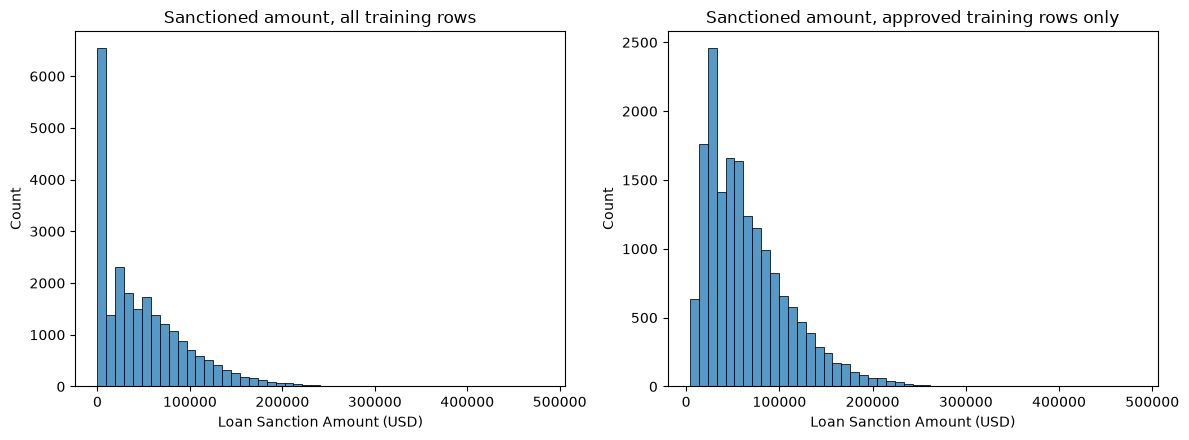

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_amount = y_amount[idx_train]
approved_train = y_train_amount > 0

zero_train = int((y_train_amount == 0).sum())
print(f"train rows at 0 : {zero_train:,}  ({zero_train / len(y_train_amount):.1%})")
print(y_train_amount[approved_train].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(y_train_amount, bins=50, ax=axes[0])
axes[0].set_title("Sanctioned amount, all training rows")
axes[0].set_xlabel("Loan Sanction Amount (USD)")

sns.histplot(y_train_amount[approved_train], bins=50, ax=axes[1])
axes[1].set_title("Sanctioned amount, approved training rows only")
axes[1].set_xlabel("Loan Sanction Amount (USD)")

plt.tight_layout()
plt.savefig("../report/figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

The left panel is a spike at 0 next to a long right tail, not a single bell
shape with a heavy side. 6,292 of the 23,457 training rows, 26.8 percent, sit
exactly on that spike, matching the rate found in block 3. Once those rows are
set aside, the right panel shows a distribution that peaks in the tens of
thousands, with a median of $55,456.86 among approved rows, and stretches out
to a maximum of $481,907.32. A single regressor fitted on the left panel has
to aim at 0 for over a quarter of the rows and at a five- or six-figure sum for
the rest, which settles on compromise numbers that fit neither group well.
Two panels this different are the visual case for the two-stage design already
argued for in words.

### Numeric columns, training rows only

The continuous columns are worth a histogram each to see which ones are close
to symmetric and which lean to one side before anything gets scaled or
transformed later in the pipeline.

Age                              0.04
Income (USD)                   137.15
Loan Amount Request (USD)        1.26
Current Loan Expenses (USD)      1.49
Credit Score                    -0.02
Property Price                   1.46

max Income (USD) in training rows: 1,777,460.21
median Income (USD) in training rows: 2,226.88


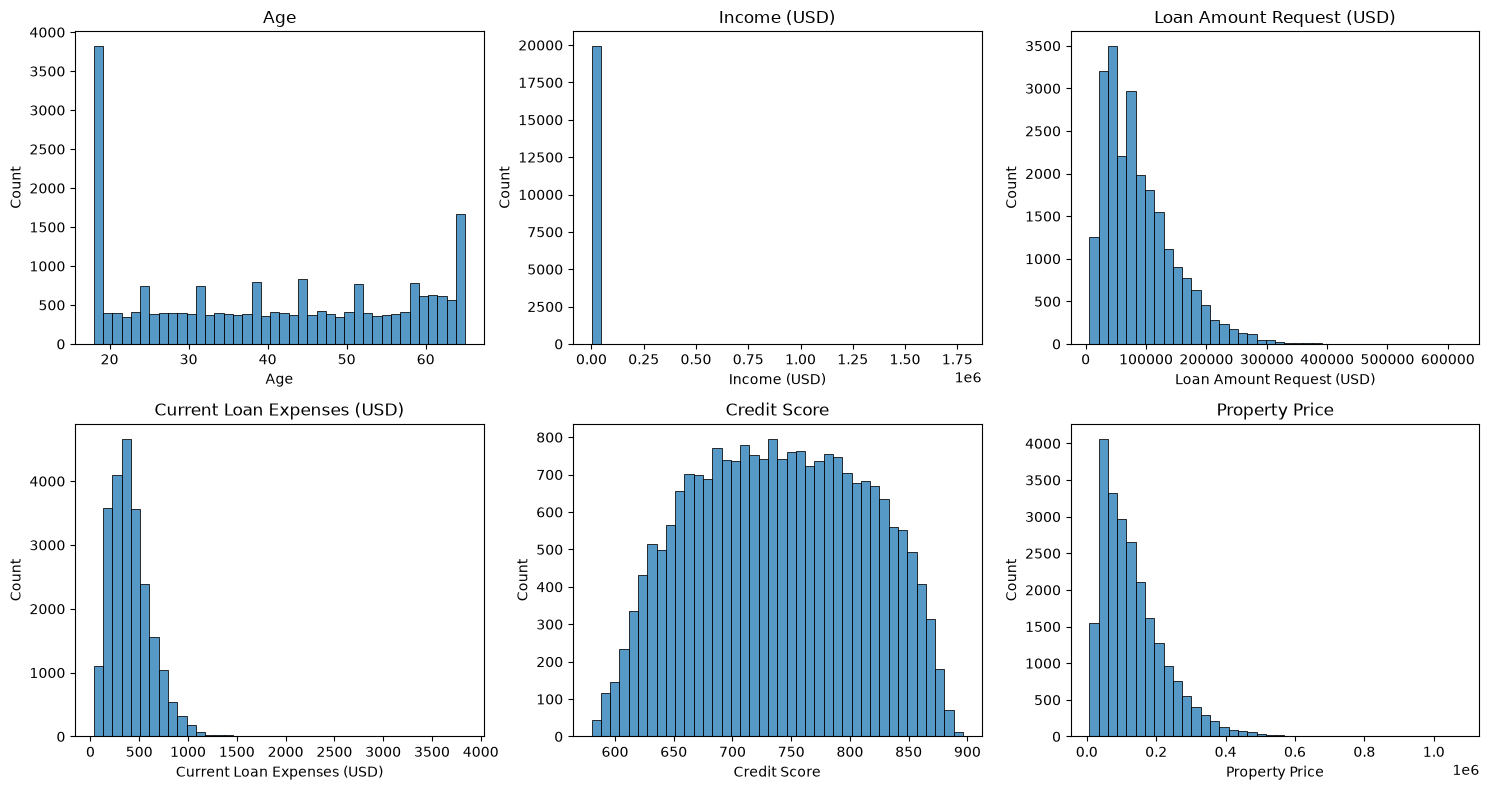

In [10]:
numeric_cols = [
    "Age",
    "Income (USD)",
    "Loan Amount Request (USD)",
    "Current Loan Expenses (USD)",
    "Credit Score",
    "Property Price",
]
print(X_train[numeric_cols].skew().round(2).to_string())
print(f"\nmax Income (USD) in training rows: {X_train['Income (USD)'].max():,.2f}")
print(f"median Income (USD) in training rows: {X_train['Income (USD)'].median():,.2f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.ravel()):
    sns.histplot(X_train[col].dropna(), bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
plt.close(fig)

`Age` and `Credit Score` come out close to symmetric, with skew of 0.04 and
-0.02, and their histograms look like it. `Loan Amount Request (USD)`,
`Current Loan Expenses (USD)` and `Property Price` carry real right skew,
between 1.26 and 1.49, which fits a market where most applicants ask for a
modest amount and a smaller number ask for a great deal more. `Income (USD)`
reports a skew of 137.15, which is not a description of the typical applicant.
The training median income is $2,226.88, yet the single largest value reaches
$1,777,460.21. One extreme row is doing almost all of the work behind that
number, not a generally skewed population, and it is the kind of column where
a median or a log transform describes it better than a plain mean further
into the pipeline.

### Categorical columns, training rows only

Bar charts of the count in each category show which fields are close to
evenly split and which are dominated by a single value, before any of them get
encoded for a model.

Gender: top category 'M', 50.3% of training rows
Income Stability: top category 'Low', 86.0% of training rows
Profession: top category 'Working', 56.4% of training rows
Location: top category 'Semi-Urban', 71.9% of training rows
Property Location: top category 'Semi-Urban', 34.6% of training rows
Has Active Credit Card: top category 'Active', 32.7% of training rows


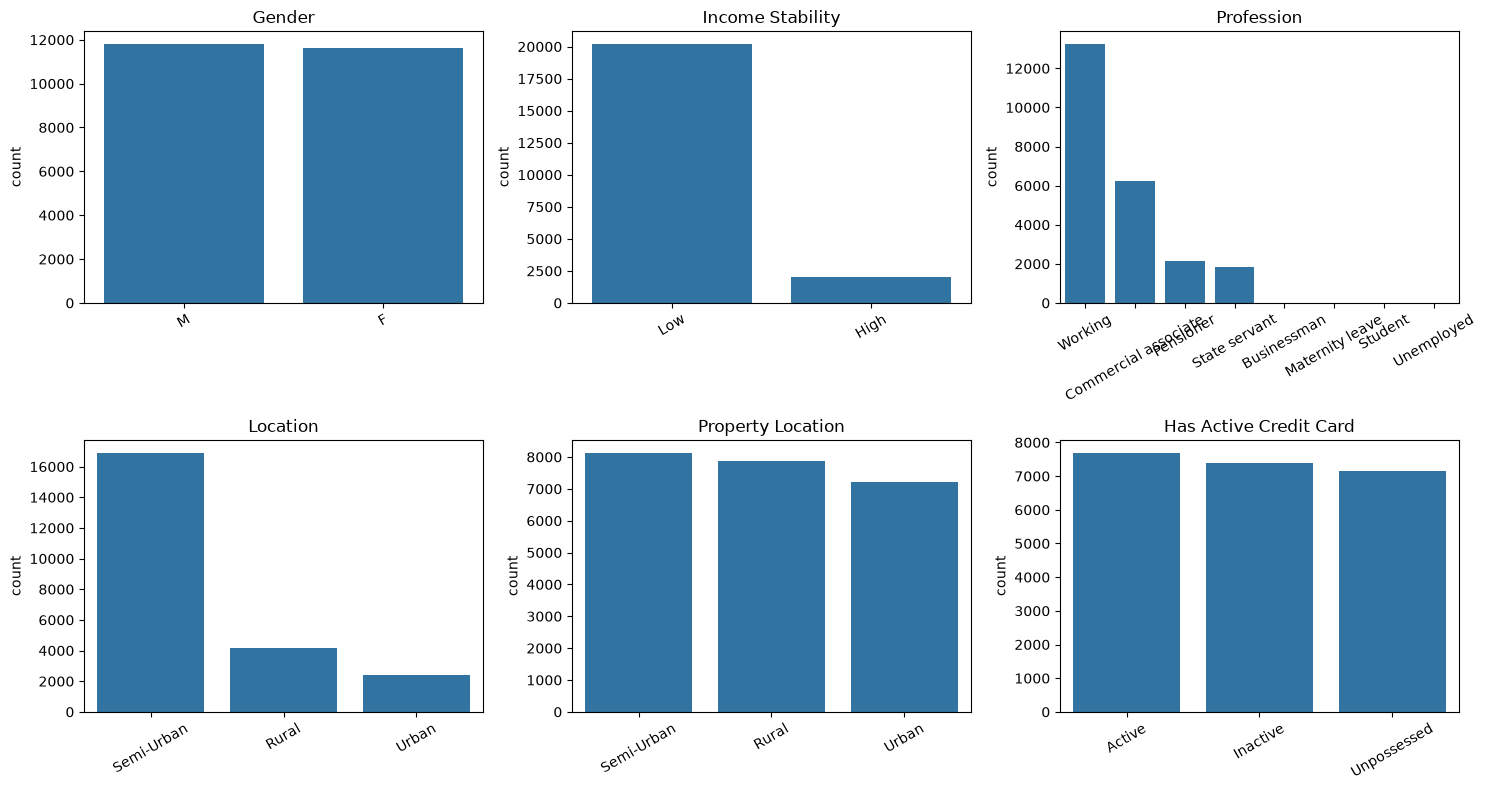

In [11]:
cat_cols = [
    "Gender",
    "Income Stability",
    "Profession",
    "Location",
    "Property Location",
    "Has Active Credit Card",
]
for col in cat_cols:
    counts = X_train[col].value_counts()
    top_share = counts.iloc[0] / len(X_train)
    print(f"{col}: top category {counts.index[0]!r}, {top_share:.1%} of training rows")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(cat_cols, axes.ravel()):
    order = X_train[col].value_counts().index
    sns.countplot(x=X_train[col], order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
plt.close(fig)

`Gender` is close to an even split, 50.3 percent male against the rest.
`Income Stability` is not: 86.0 percent of training rows are marked "Low",
so a model sees very few "High" examples to learn from. `Profession` is
dominated by "Working" at 56.4 percent, and `Location` by "Semi-Urban" at
71.9 percent. `Property Location` and `Has Active Credit Card` are the most
evenly spread of the six, with the largest category in each holding only
about a third of the rows. A column with one category near 90 percent, like
`Income Stability`, contributes little signal from its minority classes unless
that imbalance is handled explicitly later on.

### Correlation heatmap

The heatmap below covers the numeric columns of `X_train` plus the training
target, so it is read fresh rather than assumed. `Property Age` no longer
exists in `df` by this point, dropped back in block 2 because it duplicated
`Income (USD)`, so it cannot appear here and nothing about it is claimed.

Loan Sanction Amount (USD)     1.00
Loan Amount Request (USD)      0.74
Property Price                 0.71
Current Loan Expenses (USD)    0.55
Credit Score                   0.37
Co-Applicant                   0.26
Income (USD)                   0.03
Dependents                     0.01
Age                            0.01
Property Type                  0.00
No. of Defaults               -0.00

Loan Amount Request (USD) vs Property Price: 0.96


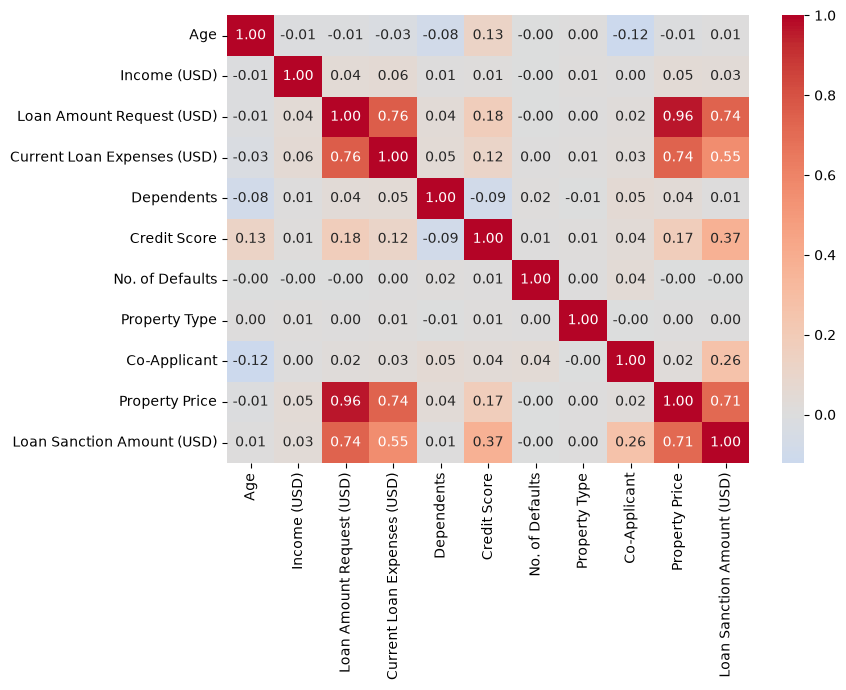

In [12]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
corr = X_train[num_cols].assign(**{"Loan Sanction Amount (USD)": y_train_amount}).corr()
print(corr["Loan Sanction Amount (USD)"].sort_values(ascending=False).round(2).to_string())
pair_corr = corr.loc["Loan Amount Request (USD)", "Property Price"]
print(f"\nLoan Amount Request (USD) vs Property Price: {pair_corr:.2f}")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.savefig("../report/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

The strongest relationships in this heatmap do not involve income at all.
`Loan Amount Request (USD)` and `Property Price` move almost together, at
0.96, which makes sense since a more expensive property is usually paired
with a larger loan request on the same application. Both of them are also the
two columns most tied to the target, at 0.74 and 0.71, with `Current Loan
Expenses (USD)` behind at 0.55 and `Credit Score` at 0.37. `Income (USD)`,
`Age`, `Dependents`, `No. of Defaults` and `Property Type` all sit under 0.05
against the target, close to no linear relationship at all. `Property Age`
is not in this table because it was dropped in block 2 for duplicating
`Income (USD)`, and no claim about it is made here.

### The strongest single relationship

`Loan Amount Request (USD)` led every other numeric column in the correlation
table above, so it is worth a closer look on its own, restricted to the
approved training rows since a refusal is recorded as 0 regardless of what was
requested.

pearson r, approved training rows only: 0.9907
sanctioned amount exceeds requested amount in 0 rows
sanctioned / requested ratio: count    17165.000
mean         0.716
std          0.054
min          0.650
25%          0.700
50%          0.700
75%          0.750
max          1.000


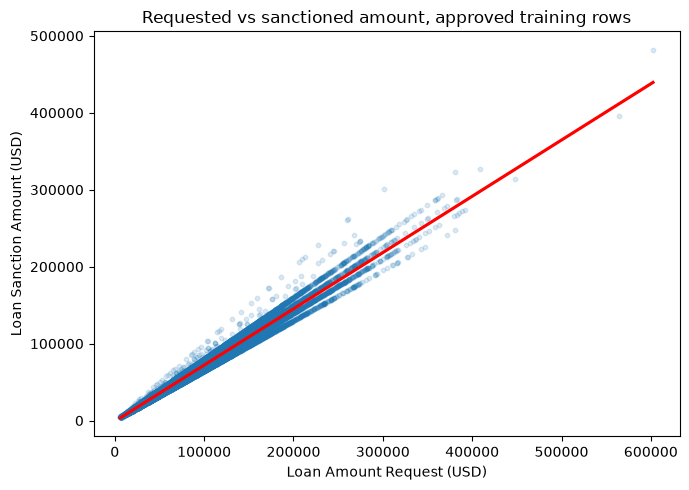

In [13]:
req_approved = X_train.loc[approved_train, "Loan Amount Request (USD)"]
sanction_approved = y_train_amount[approved_train]
ratio = sanction_approved / req_approved

r = req_approved.corr(sanction_approved)
print(f"pearson r, approved training rows only: {r:.4f}")
print(f"sanctioned amount exceeds requested amount in {(sanction_approved > req_approved).sum()} rows")
print(f"sanctioned / requested ratio: {ratio.describe().round(3).to_string()}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    x=req_approved,
    y=sanction_approved,
    scatter_kws={"alpha": 0.15, "s": 10},
    line_kws={"color": "red"},
    ax=ax,
)
ax.set_xlabel("Loan Amount Request (USD)")
ax.set_ylabel("Loan Sanction Amount (USD)")
ax.set_title("Requested vs sanctioned amount, approved training rows")
plt.tight_layout()
plt.show()
plt.close(fig)

Among approved training rows, the sanctioned amount tracks the requested
amount closely, at a Pearson correlation of 0.9907, and never once exceeds it.
The ratio of sanctioned to requested has a median of exactly 0.700, a mean of
0.716, and stays inside a narrow band from 0.650 to 1.000. Once an application
clears the approval stage, the bank is not choosing a sanctioned figure from
scratch. It is anchoring on the amount asked for and cutting it, mostly to
around 70 to 75 percent, which is a strong and specific pattern for the stage
2 regressor to pick up on.

## Preprocessing, fit only on the training rows

Three mistakes are worth naming here, each one a way to make a model look
better during development than it will ever perform on an application it has
not seen.

The first is fitting a transformer before splitting the data. If the median
used to fill a missing value, or the mean and standard deviation used to
rescale a column, are computed across every row including the ones set aside
for testing, then the test rows have already shaped a number the model
trains on. Every transformer below lives inside a `Pipeline`, and once that
pipeline is wrapped inside cross validation in a later block, it gets refit
from scratch on each training fold. A fold held out for validation is
transformed using statistics learned only from the folds that remain.

The second is coding a nominal category as an ordinal number. Turning
`Profession` into 0, 1, 2 and 3 tells a linear model that category 3 is three
times category 1, and that the step from 1 to 2 means the same thing as the
step from 2 to 3. Neither statement is true of a job title, so one-hot
encoding is used instead. It gives each category its own column and states no
order or distance between them.

The third is overwriting an outlier with the column mean. Applied to a column
that counts dependents, that produced a value of 2.23, a number of dependents
that cannot exist. Clipping at percentiles is used instead: a value above the
99th percentile is pulled down to it, and a value below the 1st percentile is
pulled up to it. Every row keeps its rank in the column, and no fractional
dependent is invented.

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin

class PercentileClipper(BaseEstimator, TransformerMixin):
    """Caps extreme values at percentiles learned from the training folds only."""

    def __init__(self, lower=1.0, upper=99.0):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        values = np.asarray(X, dtype=float)
        self.lower_ = np.nanpercentile(values, self.lower, axis=0)
        self.upper_ = np.nanpercentile(values, self.upper, axis=0)
        self.n_features_in_ = values.shape[1]
        self.feature_names_in_ = np.asarray(
            getattr(X, "columns", [f"x{i}" for i in range(values.shape[1])])
        )
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        names = input_features if input_features is not None else self.feature_names_in_
        return np.asarray(names, dtype=object)

### Why the clipper reports its own feature names

`PercentileClipper` renames no column and drops none, so `get_feature_names_out`
can look like dead code on a class that does nothing to feature names. A
`ColumnTransformer` does not see it that way. The moment anything downstream
asks the fitted pipeline for feature names, it asks every step inside every
one of its pipelines for the same method, and a single step missing it fails
the request for the whole object, not just that step, with an error such as
`AttributeError: Estimator clip does not provide get_feature_names_out`. A
later stage of this project asks a fitted pipeline for its feature names to
label a SHAP plot, so the method is kept on the class well before that stage
needs it.

The columns handed to the pipeline fall into three groups, based on what each
one needs done to it before a model can read it.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CLIP_COLS = ["Age", "Income (USD)", "Loan Amount Request (USD)",
             "Current Loan Expenses (USD)", "Credit Score", "Property Price"]
DISCRETE_COLS = ["Dependents", "No. of Defaults", "Co-Applicant"]
# Property Type is stored as an integer, but the integers are codes for a kind
# of property, not a count. Object-dtype detection alone would miss it and
# leave it in the discrete group by default, so it is added to the
# categorical group explicitly here rather than by relying on its dtype.
CATEGORICAL_COLS = [c for c in X_train.columns if X_train[c].dtype == object] + ["Property Type"]

print(f"continuous, clipped then scaled ({len(CLIP_COLS)}): {CLIP_COLS}")
print(f"discrete, scaled only ({len(DISCRETE_COLS)}): {DISCRETE_COLS}")
print(f"categorical, one-hot encoded ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")

def make_preprocessor():
    return ColumnTransformer([
        ("continuous", Pipeline([
            ("clip", PercentileClipper()),
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), CLIP_COLS),
        ("discrete", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), DISCRETE_COLS),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), CATEGORICAL_COLS),
    ])

continuous, clipped then scaled (6): ['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Credit Score', 'Property Price']
discrete, scaled only (3): ['Dependents', 'No. of Defaults', 'Co-Applicant']
categorical, one-hot encoded (10): ['Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location', 'Property Type']


`Dependents`, `No. of Defaults` and `Co-Applicant` are handled in a separate
group from the six continuous columns above, because clipping a count at a
percentile does not do what clipping does for an income or a credit score.
Those continuous columns can carry a genuine data entry error sitting far out
in the tail, and a percentile cut pulls that error back toward the bulk of
the column. A count of dependents has no equivalent error to correct. Fourteen
dependents in the training data is an unusual household, not a typo, and
cutting it down to whatever integer sits at the 99th percentile would erase a
real value rather than fix a broken one. These three columns are already
small whole numbers, `No. of Defaults` and `Co-Applicant` only ever 0 or 1 in
the training data, so they go straight to imputation and scaling with no
clipping step in between.

`Property Type` looks like it belongs in that same group, since it is stored
as an integer, but its values are codes 1 to 4 for a kind of property, not a
count of anything. Nothing about the data says type 4 is twice type 2, or
that the step from 1 to 2 means the same thing as the step from 3 to 4, so
scaling it like a quantity would invent an ordering the codes do not carry.
That is the same mistake the narration above already rules out for
`Profession`, so `Property Type` is one-hot encoded alongside the object-dtype
columns instead, added to `CATEGORICAL_COLS` by hand since its integer dtype
would otherwise leave it out of that group.

`OneHotEncoder` is set to `handle_unknown="ignore"` because the encoder is
fitted on `X_train` alone. If a category in `Type of Employment` or any other
categorical column shows up only in the test rows, meaning it never appeared
while the encoder was being fitted, the default behaviour raises an error the
moment that row is transformed, after the model has already been trained and
a prediction is expected. Setting it to ignore instead turns that one column
into zeros for that row, an honest record that nothing was learned about this
particular value, rather than a crash at the exact point a prediction is
needed.

Both claims can be checked directly instead of trusted on faith, that
`Dependents` keeps only whole numbers, and how many columns the one-hot step
actually produces.

In [16]:
check = make_preprocessor().fit(X_train)
dependents_values = sorted(X_train["Dependents"].dropna().unique())
print(f"Dependents values in training data: {dependents_values}")
assert all(float(v).is_integer() for v in dependents_values), "Dependents must stay whole"
print("Dependents are whole numbers, no fractional value was invented")
print(f"feature count after one-hot encoding: {len(check.get_feature_names_out())}")
print(f"first 8 feature names: {list(check.get_feature_names_out()[:8])}")

Dependents values in training data: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(10.0), np.float64(14.0)]
Dependents are whole numbers, no fractional value was invented
feature count after one-hot encoding: 56
first 8 feature names: ['continuous__Age', 'continuous__Income (USD)', 'continuous__Loan Amount Request (USD)', 'continuous__Current Loan Expenses (USD)', 'continuous__Credit Score', 'continuous__Property Price', 'discrete__Dependents', 'discrete__No. of Defaults']


`Dependents` holds ten distinct whole-number values in the training data,
running from 1 up to 14, and every one of them is a whole number before
anything is done to the column. That is the fact behind the design choice
made above: the raw values were never fractional to begin with, so nothing
in this pipeline needs to invent one. Standard scaling still turns the column
into small floating point numbers afterward, since that step puts every
column on the same scale for the model rather than preserving whole numbers,
but the values handed to the pipeline start out clean.

The full pipeline produces 56 features from the 19 columns handed to
`make_preprocessor()`: the 6 continuous columns and 3 discrete columns, each
contributing one column apiece, plus 47 columns from one-hot encoding the 10
categorical fields, `Property Type` among them despite being stored as a
number. The first eight names, in the order the `ColumnTransformer` assembles
them, cover all six continuous columns before moving on to the first two
discrete ones, each still labelled with the group it belongs to.

This is what `make_preprocessor()` hands to every block still to come, a
function, not a fitted object. Calling it again builds a fresh, unfitted
`ColumnTransformer`, so a classifier trained in one block and a regressor
trained in another each fit their own copy of it inside their own cross
validation, rather than sharing statistics learned by whichever model
happened to run first.

## Stage 1, is anything sanctioned at all

The audit in block 3 found that 26.8 percent of applications are refused
outright, and the split in block 4 carried that same rate into both
`y_train_cls` and `y_test_cls` below. Stage 1 answers the yes-or-no question
first: does this application receive any sanctioned amount at all. Only the
applications it passes ever reach the stage 2 regressor built in the next
block. Everything in this block trains on `X_train` and reports its final
numbers on `X_test`, the same split fixed back in block 4.

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_train_cls, y_test_cls = y_approved[idx_train], y_approved[idx_test]

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train_cls)
base_pred = baseline.predict(X_test)
print(f"always-approve baseline   accuracy {accuracy_score(y_test_cls, base_pred):.4f}   F1 {f1_score(y_test_cls, base_pred):.4f}")

always-approve baseline   accuracy 0.7318   F1 0.8451


The baseline reaches an accuracy of 0.7318 and an F1 of 0.8451, and both
numbers already appeared in the introduction to this notebook as the bar a
real model has to clear. That accuracy is not a sign the baseline understands
anything about an application. It is the reward for guessing "approved" on
every single row, since 73.2 percent of the test set is approved regardless
of what the model does. F1 does not hand out that reward for free, since it
drops the moment a model stops catching refusals, so F1 rather than accuracy
decides which of the three tuned candidates below is kept.

### Tuning three candidates

Each candidate is wrapped in a `Pipeline` with `make_preprocessor()` as the
first step, so every cross validation fold refits its own imputer, scaler and
encoder on the training folds only, exactly as argued for in block 6. The
grids are kept small on purpose. This is a search over three model families,
not an exhaustive sweep of any one of them, and a full run across all three
still has to finish in a reasonable time.

- Logistic regression, tuned over the regularisation strength `C`.
- Random forest, tuned over tree depth and the minimum samples allowed in a
  leaf.
- Gradient boosting, tuned over the learning rate and tree depth.

Every search scores on F1 with 5-fold cross validation. `error_score="raise"`
is set on all three for a reason spelled out in the code comment below, not
left to the default.

In [18]:
import joblib
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


def fit_or_load(name, search, X, y):
    """Fits a grid search once, then caches the winner and its params to disk.

    A GridSearchCV object is not what gets saved, since dumping the whole
    search would also dump every fold's fitted copy. Only best_estimator_ is
    kept, so best_params_ is captured into the same dict before the search
    object goes out of scope, and that dict is what a cached rerun loads back.
    """
    path = MODELS / f"{name}.joblib"
    if path.exists() and not RETRAIN:
        print(f"loading cached {name}")
        return joblib.load(path)
    print(f"fitting {name}")
    search.fit(X, y)
    result = {"estimator": search.best_estimator_, "best_params": search.best_params_}
    joblib.dump(result, path)
    return result


# error_score="raise" stops a failed fit from being scored as NaN and averaged
# in as if it were a real result. The earlier version of this project ran
# without it and 180 of 540 fits failed silently, so the search reported a
# winner picked from a third fewer candidates than the grid appeared to hold,
# and nothing on screen showed the gap.
search_logreg = GridSearchCV(
    Pipeline([("pre", make_preprocessor()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    {"model__C": [0.1, 1.0, 10.0]},
    scoring="f1", cv=5, n_jobs=-1, error_score="raise",
)
search_rf = GridSearchCV(
    Pipeline([("pre", make_preprocessor()), ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]),
    {"model__max_depth": [None, 15], "model__min_samples_leaf": [1, 5]},
    scoring="f1", cv=5, n_jobs=-1, error_score="raise",
)
search_gb = GridSearchCV(
    Pipeline([("pre", make_preprocessor()), ("model", GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE))]),
    {"model__learning_rate": [0.05, 0.1], "model__max_depth": [3, 5]},
    scoring="f1", cv=5, n_jobs=-1, error_score="raise",
)

result_logreg = fit_or_load("stage1_logreg", search_logreg, X_train, y_train_cls)
print(f"logistic regression best params: {result_logreg['best_params']}")

result_rf = fit_or_load("stage1_random_forest", search_rf, X_train, y_train_cls)
print(f"random forest best params: {result_rf['best_params']}")

result_gb = fit_or_load("stage1_gradient_boosting", search_gb, X_train, y_train_cls)
print(f"gradient boosting best params: {result_gb['best_params']}")

loading cached stage1_logreg
logistic regression best params: {'model__C': 10.0}
loading cached stage1_random_forest
random forest best params: {'model__max_depth': 15, 'model__min_samples_leaf': 1}
loading cached stage1_gradient_boosting
gradient boosting best params: {'model__learning_rate': 0.05, 'model__max_depth': 5}


Grid search settled on `C = 10.0` for logistic regression, a max depth of 15
with a minimum leaf size of 1 for the random forest, and a learning rate of
0.05 with a max depth of 5 for gradient boosting. Each grid only offered a
handful of values, so this says where each model prefers to sit among the
options tried, not a finely tuned optimum.

### Comparing all four on the held-out test set

Every model above, plus the baseline, is now scored on `X_test`, which none
of them has been fitted on or tuned against. The five metrics are collected
into a single table so the comparison sits in one place rather than being
read off separate print statements.

In [19]:
models_cls = {
    "baseline (always approve)": baseline,
    "logistic regression": result_logreg["estimator"],
    "random forest": result_rf["estimator"],
    "gradient boosting": result_gb["estimator"],
}

rows = []
for name, m in models_cls.items():
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test_cls, pred),
        "precision": precision_score(y_test_cls, pred),
        "recall": recall_score(y_test_cls, pred),
        "f1": f1_score(y_test_cls, pred),
        "roc_auc": roc_auc_score(y_test_cls, proba),
    })

stage1_metrics = pd.DataFrame(rows).set_index("model").round(4)
print(stage1_metrics.to_string())

best_name = stage1_metrics["f1"].idxmax()
best_classifier = models_cls[best_name]
print(f"\nwinner by F1: {best_name}")

                           accuracy  precision  recall      f1  roc_auc
model                                                                  
baseline (always approve)    0.7318     0.7318  1.0000  0.8451   0.5000
logistic regression          0.8805     0.8697  0.9842  0.9234   0.8582
random forest                0.9158     0.8971  0.9995  0.9456   0.8866
gradient boosting            0.9168     0.8982  0.9995  0.9462   0.8894



winner by F1: gradient boosting


All three tuned candidates clear the baseline by a wide margin on F1.
Logistic regression reaches 0.9234, the random forest 0.9456 and gradient
boosting 0.9462, each well above the baseline's 0.8451. Gradient boosting
also leads on accuracy, precision and ROC-AUC, at 0.9168, 0.8982 and 0.8894
respectively, so it wins on more than F1 alone and becomes `best_classifier`
for the rest of this notebook. Recall sits at 0.98 or higher for all three
tuned models, since an approved row is the easier half of this target to get
right and there are more of them to learn from. Precision, at 0.8982 for the
winner, is where the harder half of the job shows up: telling a refusal
apart from an approval.

correctly refused (true negative)  : 1087
false approval (false positive)    : 486
false rejection (false negative)   : 2
correctly approved (true positive) : 4290


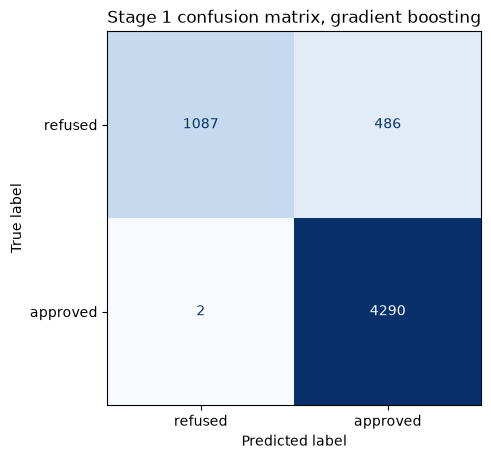

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test_cls, best_classifier.predict(X_test))
tn, fp, fn, tp = cm.ravel()
print(f"correctly refused (true negative)  : {tn}")
print(f"false approval (false positive)    : {fp}")
print(f"false rejection (false negative)   : {fn}")
print(f"correctly approved (true positive) : {tp}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["refused", "approved"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Stage 1 confusion matrix, {best_name}")
plt.tight_layout()
plt.savefig("../report/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

The confusion matrix puts a count behind the two kinds of mistake this model
can make. A false approval is a row marked approved when it was actually
refused, so that applicant is later quoted a sanctioned amount by the stage 2
regressor that never arrives. A false rejection is the opposite: a row marked
refused when it was actually approved, so a viable applicant is turned away
and discouraged before ever reaching stage 2.

Gradient boosting produces 486 false approvals against only 2 false
rejections on the test set, so the false-approval mistake is overwhelmingly
the more common of the two, not the false-rejection one. Set against the
1,573 applications actually refused in the test set, that is roughly 3 in 10
refused applicants wrongly told a number is coming. Almost no viable
applicant is turned away by mistake, at 2 out of 4,292 approved rows, but a
real minority of refusals slip through disguised as approvals. Anyone acting
on this model should expect it to occasionally promise money a refusal will
never pay out, far more often than it discourages someone who would have
qualified.

### Where each classifier sits away from its single 0.5 score

Every number reported above for these three classifiers, accuracy,
precision, recall and F1, is read off `predict()` at one fixed cutoff of 0.5.
None of them describes what happens at any other cutoff. Each classifier
here outputs a probability of approval rather than a flat yes or no, and
sliding the cutoff used to turn that probability into a decision from 0 up to
1 trades catching more true approvals against wrongly waving through
applications that were actually refused. A ROC curve traces that trade-off
across every cutoff at once, rather than the single point `predict()` already
commits to, and the panel below marks where that 0.5 cutoff actually lands on
it for each of the three tuned classifiers. The always-approve baseline is
not drawn again here as a fourth curve, since its ROC-AUC of exactly 0.5000
is the dashed diagonal chance line already sitting on every panel.

logistic regression  AUC 0.8582   0.5 threshold -> FPR 0.3980   TPR 0.9842
random forest        AUC 0.8866   0.5 threshold -> FPR 0.3121   TPR 0.9995
gradient boosting    AUC 0.8894   0.5 threshold -> FPR 0.3090   TPR 0.9991


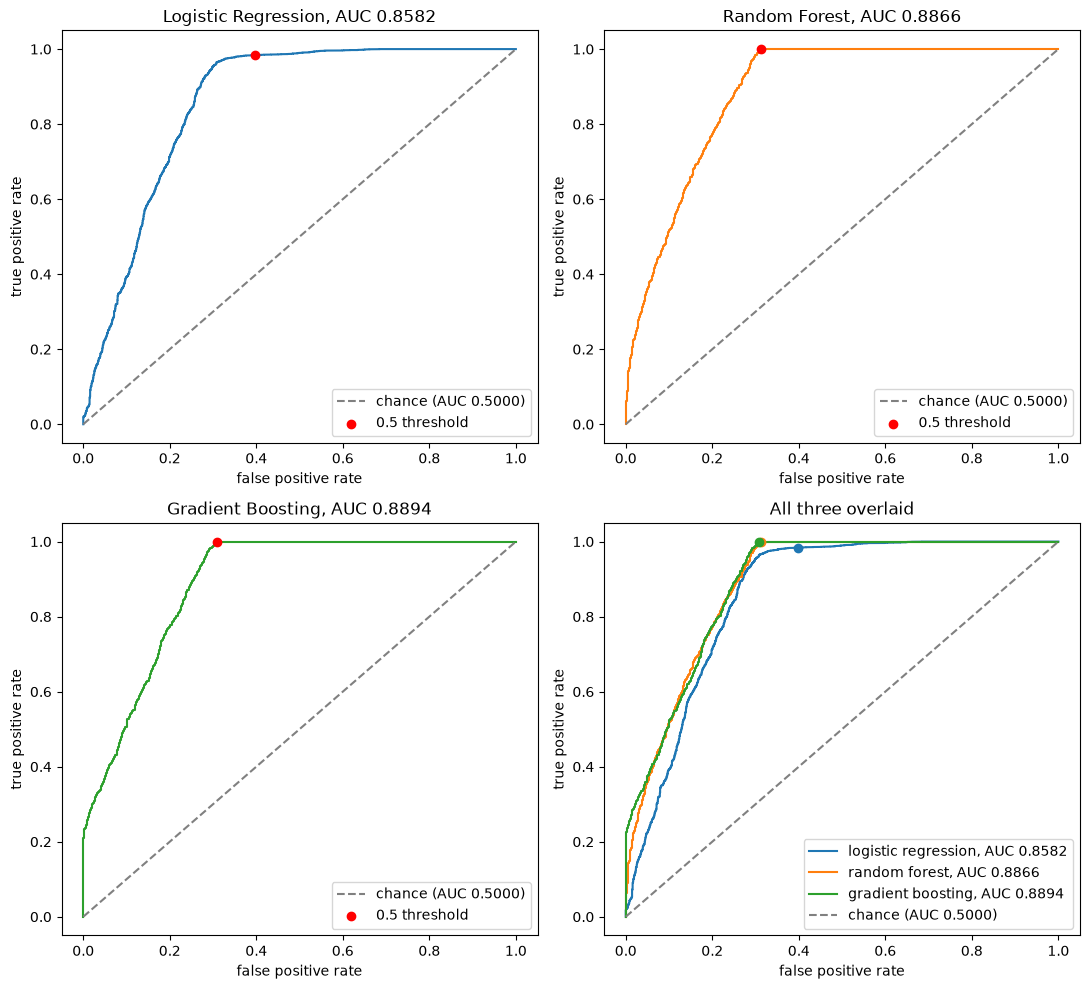

In [21]:
from sklearn.metrics import roc_curve


def operating_point(thresholds):
    """Index of the threshold closest to 0.5. roc_curve returns thresholds in
    decreasing order and can prepend an infinite first entry in recent
    scikit-learn versions, so that entry is excluded before comparing."""
    finite_idx = np.where(np.isfinite(thresholds))[0]
    return finite_idx[np.argmin(np.abs(thresholds[finite_idx] - 0.5))]


roc_models = {
    "logistic regression": models_cls["logistic regression"],
    "random forest": models_cls["random forest"],
    "gradient boosting": models_cls["gradient boosting"],
}
roc_colors = {
    "logistic regression": "tab:blue",
    "random forest": "tab:orange",
    "gradient boosting": "tab:green",
}

roc_data = {}
for roc_name, roc_model in roc_models.items():
    roc_proba = roc_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_cls, roc_proba)
    op_idx = operating_point(thresholds)
    roc_data[roc_name] = {
        "fpr": fpr, "tpr": tpr,
        "auc": roc_auc_score(y_test_cls, roc_proba),
        "op_fpr": fpr[op_idx], "op_tpr": tpr[op_idx],
    }
    print(
        f"{roc_name:20s} AUC {roc_data[roc_name]['auc']:.4f}   "
        f"0.5 threshold -> FPR {roc_data[roc_name]['op_fpr']:.4f}   "
        f"TPR {roc_data[roc_name]['op_tpr']:.4f}"
    )

fig, axes = plt.subplots(2, 2, figsize=(11, 10))

single_panels = [
    (axes[0, 0], "logistic regression"),
    (axes[0, 1], "random forest"),
    (axes[1, 0], "gradient boosting"),
]
for ax, roc_name in single_panels:
    d = roc_data[roc_name]
    ax.plot(d["fpr"], d["tpr"], color=roc_colors[roc_name])
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance (AUC 0.5000)")
    ax.scatter([d["op_fpr"]], [d["op_tpr"]], color="red", zorder=5, label="0.5 threshold")
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    ax.set_title(f"{roc_name.title()}, AUC {d['auc']:.4f}")
    ax.legend(loc="lower right")

ax_overlay = axes[1, 1]
for roc_name in roc_models:
    d = roc_data[roc_name]
    ax_overlay.plot(d["fpr"], d["tpr"], color=roc_colors[roc_name], label=f"{roc_name}, AUC {d['auc']:.4f}")
    ax_overlay.scatter([d["op_fpr"]], [d["op_tpr"]], color=roc_colors[roc_name], zorder=5)
ax_overlay.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance (AUC 0.5000)")
ax_overlay.set_xlabel("false positive rate")
ax_overlay.set_ylabel("true positive rate")
ax_overlay.set_title("All three overlaid")
ax_overlay.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../report/figures/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

Logistic regression reaches an AUC of 0.8582, the random forest 0.8866 and
gradient boosting 0.8894, the same ranking already seen in the metrics table
above. Random forest and gradient boosting differ by only 0.0028 AUC, close
enough that their curves nearly coincide on one shared axes, which is why
each keeps a panel of its own alongside the overlay rather than being read
off a single crowded plot.

The marked point on gradient boosting's curve is the part worth reading
slowly. Its 0.5 cutoff sits high up the curve, where true positive rate is
already close to 1 and false positive rate has climbed well off the bottom
left corner. That position is the same trade-off already reported from the
confusion matrix, seen here as a location on the curve rather than a table of
counts: catching almost every real approval costs a real share of wrongly
approved refusals. Gradient boosting's marked point sits at a false positive
rate and true positive rate that reproduce the block's confusion matrix
exactly, printed above the four panels.

The dashed diagonal on every panel is the always-approve baseline, at exactly
0.5000 AUC, not a fourth curve competing with the other three.

## Stage 2, how much is sanctioned

Stage 1 decided whether an application is sanctioned anything at all. Stage 2
answers the second question, and only for the rows where that answer was yes.
A row with a sanction of 0 belongs to stage 1, not here, so it is removed from
both training and scoring before a single model is touched.

Block 5 already looked closely at the approved rows in `X_train` and found
that the sanctioned amount tracks the requested amount at a Pearson
correlation of 0.9907, never exceeds it, and sits at a median of 70 percent of
it. That is close to an easy problem, not a hard one, and the numbers below
bear that out. The harder half of this project is stage 1, where refusal has
to be read off applicant details with no such anchor to lean on.

In [22]:
approved_train = idx_train[y_approved[idx_train] == 1]
approved_test = idx_test[y_approved[idx_test] == 1]
X_train_amt, y_train_amt = X_train.loc[approved_train], y_amount[approved_train]
X_test_amt, y_test_amt = X_test.loc[approved_test], y_amount[approved_test]
print(f"stage 2 trains on {len(approved_train):,} approved rows, tests on {len(approved_test):,} approved rows")

stage 2 trains on 17,165 approved rows, tests on 4,292 approved rows


17,165 approved training rows and 4,292 approved test rows go into stage 2,
17,165 / 23,457 and 4,292 / 5,865 both landing at the same 73.2 percent
approval rate block 4's stratified split fixed for the whole project. Neither
`idx_test` nor `approved_test` is passed to a `fit` call anywhere in this
block. They only appear on the right-hand side of a `predict` or inside a
scoring function, once for every model below.

### The bar to clear

`DummyRegressor(strategy="mean")` always predicts the mean sanctioned amount
among approved training rows, regardless of what the application looks like.
It is fitted on `X_train_amt` and `y_train_amt` and scored on the approved
test rows set aside above, in USD, so every model tried afterward has a
number to beat before it is taken seriously.

In [23]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

baseline_reg = DummyRegressor(strategy="mean")
baseline_reg.fit(X_train_amt, y_train_amt)
base_pred = baseline_reg.predict(X_test_amt)
print(f"dummy (mean) baseline   RMSE {root_mean_squared_error(y_test_amt, base_pred):,.2f}   MAE {mean_absolute_error(y_test_amt, base_pred):,.2f}   R2 {r2_score(y_test_amt, base_pred):.4f}")

dummy (mean) baseline   RMSE 44,861.14   MAE 35,106.15   R2 -0.0000


The mean predictor misses by $44,861.14 on average (RMSE) and its R2 rounds
to -0.0000, the score a constant prediction always earns on data it never
looked at. That RMSE is close to the standard deviation of the approved
sanctioned amount itself, which is what a model with no information about the
application is reduced to reporting.

### Five candidates

- **Linear Regression**, no tuning needed, kept as a simple, readable model
  the more complex ones have to justify improving on.
- **PCA then Linear Regression**, compressing the preprocessed features down
  to 10 components before fitting.
- **Random Forest**, tuned over tree count, depth, leaf size and the feature
  sampling rule.
- **Gradient Boosting**, tuned over learning rate, depth, tree count and the
  subsample fraction.
- **A PyTorch neural network**, in place of a Keras model that has no way to
  run in this environment, described in its own section below.

The first four are each wrapped in `Pipeline([("pre", make_preprocessor()), ...])`.
`make_preprocessor()` is refit here on `X_train_amt`, the approved training
rows only, rather than on the full `X_train` block 6 used, so the categories
the one-hot encoder has ever seen shrink to whatever appears among applicants
who were actually approved. Both grid searches below score on
`neg_root_mean_squared_error` with 5-fold cross validation, the same rule for
both, since picking one model on one criterion and a second model on a
different one is what made an earlier version of this kind of comparison
report the wrong winner. `error_score="raise"` is set on both for the same
reason block 7 already gave: a bad grid should fail loudly, not score `NaN`
and get quietly averaged away.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipe_linear = Pipeline([("pre", make_preprocessor()), ("model", LinearRegression())])
pipe_linear.fit(X_train_amt, y_train_amt)
pred_linear = pipe_linear.predict(X_test_amt)

n_features_stage2 = len(pipe_linear.named_steps["pre"].get_feature_names_out())
print(f"features after preprocessing, approved rows only: {n_features_stage2}")
print(f"linear regression   RMSE {root_mean_squared_error(y_test_amt, pred_linear):,.2f}   MAE {mean_absolute_error(y_test_amt, pred_linear):,.2f}   R2 {r2_score(y_test_amt, pred_linear):.4f}")

features after preprocessing, approved rows only: 54
linear regression   RMSE 6,339.64   MAE 3,925.84   R2 0.9800


Fitting `make_preprocessor()` on the approved rows alone produces 54 features,
two fewer than block 6's 56. Only 2 rows in the whole training set carry a
`Profession` of "Unemployed" or "Student", and both of them are refused, so
neither category is ever seen once the one-hot encoder is fit on approved
rows only, and those two columns simply do not exist in this stage's feature
space.

Linear regression alone reaches an RMSE of $6,339.64 and an R2 of 0.9800,
already a large step down from the dummy baseline's $44,861.14. That figure
lines up with block 5's 0.9907 correlation between requested and sanctioned
amount, since the requested amount is one of the 19 columns handed to this
model and carries most of the weight in it, a point checked directly further
down this block.

In [25]:
from sklearn.decomposition import PCA

pipe_pca = Pipeline([
    ("pre", make_preprocessor()),
    ("pca", PCA(n_components=10, random_state=RANDOM_STATE)),
    ("model", LinearRegression()),
])
pipe_pca.fit(X_train_amt, y_train_amt)
pred_pca = pipe_pca.predict(X_test_amt)
cum_var = pipe_pca.named_steps["pca"].explained_variance_ratio_.sum()
print(f"cumulative explained variance, 10 components: {cum_var:.4f}")
print(f"pca + linear regression   RMSE {root_mean_squared_error(y_test_amt, pred_pca):,.2f}   MAE {mean_absolute_error(y_test_amt, pred_pca):,.2f}   R2 {r2_score(y_test_amt, pred_pca):.4f}")

cumulative explained variance, 10 components: 0.7123
pca + linear regression   RMSE 11,428.85   MAE 8,066.47   R2 0.9351


Ten components out of 54 carry 71.23 percent of the variance in the
preprocessed features, which is most of it but not nearly all of it, and that
gap shows up directly in the score. R2 drops from 0.9800 for plain linear
regression to 0.9351 once the features are compressed first, and RMSE rises
from $6,339.64 to $11,428.85, an increase of 80 percent. Ten components would
be a reasonable claim to make only if the performance held up alongside it.
It does not, so this is not read as "ten components are enough", it is read
as compression bought at a real and visible cost.

In [26]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV

search_rf_reg = GridSearchCV(
    Pipeline([("pre", make_preprocessor()), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
    {
        "model__n_estimators": [100, 300],
        "model__max_depth": [None, 15],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": [None, "sqrt"],
    },
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1, error_score="raise",
)
search_gb_reg = GridSearchCV(
    Pipeline([("pre", make_preprocessor()), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),
    {
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5],
        "model__n_estimators": [100, 200],
        "model__subsample": [0.8, 1.0],
    },
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1, error_score="raise",
)

result_rf_reg = fit_or_load("stage2_random_forest", search_rf_reg, X_train_amt, y_train_amt)
print(f"random forest best params: {result_rf_reg['best_params']}")
pred_rf = result_rf_reg["estimator"].predict(X_test_amt)
print(f"random forest   RMSE {root_mean_squared_error(y_test_amt, pred_rf):,.2f}   MAE {mean_absolute_error(y_test_amt, pred_rf):,.2f}   R2 {r2_score(y_test_amt, pred_rf):.4f}")

result_gb_reg = fit_or_load("stage2_gradient_boosting", search_gb_reg, X_train_amt, y_train_amt)
print(f"gradient boosting best params: {result_gb_reg['best_params']}")
pred_gb = result_gb_reg["estimator"].predict(X_test_amt)
print(f"gradient boosting   RMSE {root_mean_squared_error(y_test_amt, pred_gb):,.2f}   MAE {mean_absolute_error(y_test_amt, pred_gb):,.2f}   R2 {r2_score(y_test_amt, pred_gb):.4f}")

loading cached stage2_random_forest


random forest best params: {'model__max_depth': 15, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}


random forest   RMSE 5,208.24   MAE 3,230.15   R2 0.9865
loading cached stage2_gradient_boosting
gradient boosting best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}
gradient boosting   RMSE 5,137.77   MAE 3,143.83   R2 0.9869


Grid search settled on a max depth of 15, no cap on the features considered
at each split, a minimum leaf size of 2 and 300 trees for the random forest,
against a learning rate of 0.05, a max depth of 3, 200 trees and no row
subsampling for gradient boosting. Gradient boosting comes out slightly ahead
on every metric, RMSE $5,137.77 against $5,208.24, MAE $3,143.83 against
$3,230.15 and R2 0.9869 against 0.9865, though the two sit close enough that
either would be a reasonable choice. Both beat plain linear regression by a
real margin and beat the PCA version by a wide one, and both are the same
model family that won stage 1, a coincidence about the data rather than a
sign that anything from the stage 1 fit carries over.

### The fifth candidate, a PyTorch network in place of Keras

The kernel this notebook runs on is Python 3.14.4, and no TensorFlow wheel
exists for that version, so a Keras model cannot be imported here at all,
never mind run. The network below is the same topology ported to PyTorch, and
several of its settings exist only to cancel out a default that Keras and
PyTorch disagree on, each one commented where it is applied. A standalone run
of this port was checked against the original Keras figures before this
notebook was written and lands within half a percent of them, so the
settings are used as given rather than re-derived here.

In [27]:
nn_preprocessor = make_preprocessor()
X_train_nn = nn_preprocessor.fit_transform(X_train_amt).astype(np.float32)
X_test_nn = nn_preprocessor.transform(X_test_amt).astype(np.float32)

# Standardised on approved training targets only. Every metric printed for this
# model further down is converted back out of this scale into USD first.
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()
y_train_nn = target_scaler.fit_transform(y_train_amt.to_numpy().reshape(-1, 1)).astype(np.float32)
print(f"neural network input features: {X_train_nn.shape[1]}")

neural network input features: 54


In [28]:
import torch
import torch.nn as nn

torch.manual_seed(RANDOM_STATE)

def build_mlp(n_features):
    model = nn.Sequential(
        nn.Linear(n_features, 64), nn.ReLU(),
        nn.Linear(64, 128), nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64), nn.ReLU(),
        # eps 1e-3 matches keras BatchNormalization's default. Keras tracks running
        # statistics with momentum 0.99, and torch's momentum argument is defined as
        # 1 minus that figure, so 0.01 here is the same running average, not its opposite.
        nn.BatchNorm1d(64, eps=1e-3, momentum=0.01),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 32), nn.ReLU(),
        nn.BatchNorm1d(32, eps=1e-3, momentum=0.01),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 16), nn.ReLU(),
        nn.Linear(16, 1),
    )
    for layer in model:
        if isinstance(layer, nn.Linear):
            # keras Dense defaults to glorot (xavier) uniform init, torch's default does not
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
    return model

mlp = build_mlp(X_train_nn.shape[1])
for i, layer in enumerate(mlp):
    print(i, type(layer).__name__)

0 Linear
1 ReLU
2 Linear
3 ReLU
4 Dropout
5 Linear
6 ReLU
7 BatchNorm1d
8 Linear
9 ReLU
10 Linear
11 ReLU
12 BatchNorm1d
13 Linear
14 ReLU
15 Linear
16 ReLU
17 Linear


A Keras `kernel_regularizer=l2(x)` on one Dense layer only ever penalises that
layer's own weight matrix, so reproducing it as a global `weight_decay` on the
optimiser would be a different model, one that penalises every layer instead
of the three the original one did. The fix has to reach into the loss and add
the penalty for exactly those three layers, which means the three indices
have to point at real `Linear` layers before anything is built on top of them,
not assumed to.

The printout above answers that directly. Index 2 is a `Linear` layer, but
indices 7 and 12 land on `BatchNorm1d`, not `Linear`, and a `BatchNorm1d`
layer has no kernel for a Keras-style l2 penalty to attach to in the first
place, in Keras or here. The penalty below is placed on the nearest `Linear`
layer immediately after each `BatchNorm1d` instead, indices 8 and 13, so three
`Linear` layers still carry the three lambda values, 0.3, 0.1 and 0.5, just
not at the two indices that fail this check.

In [29]:
l2_layers = [(mlp[2], 0.3), (mlp[8], 0.1), (mlp[13], 0.5)]
for layer, lam in l2_layers:
    assert isinstance(layer, nn.Linear), f"expected Linear, got {type(layer).__name__}"
print("layers carrying the l2 penalty:", [(i, type(l).__name__, lam) for i, (l, lam) in zip((2, 8, 13), l2_layers)])

layers carrying the l2 penalty: [(2, 'Linear', 0.3), (8, 'Linear', 0.1), (13, 'Linear', 0.5)]


In [30]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_train_nn, y_train_nn, test_size=0.2, random_state=RANDOM_STATE
)

train_ds = TensorDataset(torch.from_numpy(X_tr_nn), torch.from_numpy(y_tr_nn))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
X_val_t = torch.from_numpy(X_val_nn)
y_val_t = torch.from_numpy(y_val_nn)

# eps 1e-7 matches keras Adam's default. torch's own default is 1e-8.
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001, eps=1e-7)
loss_fn = nn.MSELoss()

train_losses, val_losses = [], []
for epoch in range(50):
    mlp.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = mlp(xb)
        mse = loss_fn(pred, yb)
        # Each of these three layers gets its own l2 term added straight into the
        # loss, which is what keeps the penalty on exactly those layers rather than
        # spread across the whole network the way weight_decay would spread it.
        penalty = sum(lam * (layer.weight ** 2).sum() for layer, lam in l2_layers)
        (mse + penalty).backward()
        optimizer.step()
        running += mse.item() * xb.size(0)
    train_losses.append(running / len(train_ds))

    mlp.eval()
    with torch.no_grad():
        val_pred = mlp(X_val_t)
        val_losses.append(loss_fn(val_pred, y_val_t).item())

best_val_epoch = int(np.argmin(val_losses)) + 1
print(f"epoch 1                    train loss (scaled) {train_losses[0]:.4f}   val loss (scaled) {val_losses[0]:.4f}")
print(f"epoch {best_val_epoch} (lowest val loss)   train loss (scaled) {train_losses[best_val_epoch - 1]:.4f}   val loss (scaled) {val_losses[best_val_epoch - 1]:.4f}")
print(f"epoch 50                   train loss (scaled) {train_losses[-1]:.4f}   val loss (scaled) {val_losses[-1]:.4f}")

epoch 1                    train loss (scaled) 0.2127   val loss (scaled) 0.1316
epoch 25 (lowest val loss)   train loss (scaled) 0.0444   val loss (scaled) 0.0513
epoch 50                   train loss (scaled) 0.0400   val loss (scaled) 0.1850


The validation split above is carved out of `X_train_nn` and `y_train_nn`
only, the approved training rows, so this loss curve never touches
`approved_test`. Training loss falls from 0.2127 at the first epoch to 0.0400
by the fiftieth, but validation loss does not follow it down the same way. It
reaches its lowest point of 0.0513 at epoch 25, then climbs back up to 0.1850
by epoch 50 while training loss is still falling. That gap between a training
loss still improving and a validation loss going the other way is
overfitting, plainly present in this run, and the network below is evaluated
after the full 50 epochs regardless, not at its best validation epoch, since
epoch selection was never part of this design.

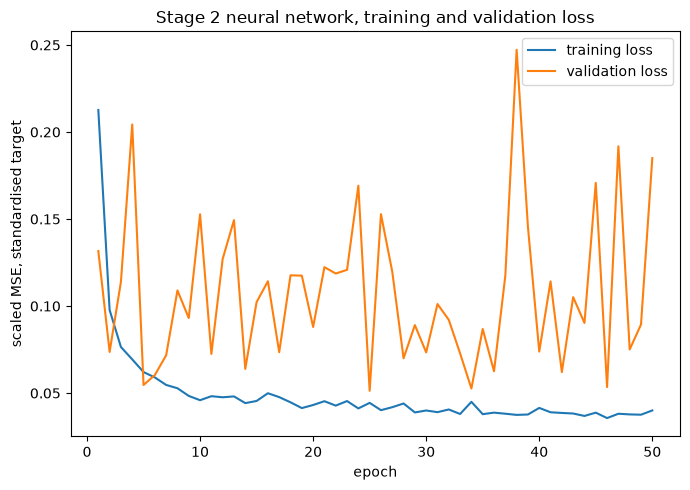

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, 51), train_losses, label="training loss")
ax.plot(range(1, 51), val_losses, label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("scaled MSE, standardised target")
ax.set_title("Stage 2 neural network, training and validation loss")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/nn_loss.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [32]:
class TorchMLPRegressor:
    """Wraps the fitted preprocessor, network and target scaler behind one predict(X)
    call, so this model can stand in for best_regressor exactly like an sklearn pipeline."""

    def __init__(self, preprocessor, model, target_scaler):
        self.preprocessor = preprocessor
        self.model = model
        self.target_scaler = target_scaler

    def predict(self, X):
        X_pre = self.preprocessor.transform(X).astype(np.float32)
        self.model.eval()
        with torch.no_grad():
            pred_scaled = self.model(torch.from_numpy(X_pre)).numpy()
        return self.target_scaler.inverse_transform(pred_scaled).ravel()

nn_regressor = TorchMLPRegressor(nn_preprocessor, mlp, target_scaler)
pred_nn = nn_regressor.predict(X_test_amt)
print(f"neural network   RMSE {root_mean_squared_error(y_test_amt, pred_nn):,.2f}   MAE {mean_absolute_error(y_test_amt, pred_nn):,.2f}   R2 {r2_score(y_test_amt, pred_nn):.4f}")

neural network   RMSE 18,636.00   MAE 14,464.95   R2 0.8274


The network lands at an RMSE of $18,636.00 and an R2 of 0.8274, clearly
behind every other model tried in this block, including plain linear
regression. That is consistent with the overfitting already visible in its
own loss curve, and with a more general pattern in this kind of problem: a
handful of tabular columns rarely gives a deep network enough to exploit that
a tree ensemble was not already positioned to find more directly.

### Checking these scores are not too good to be true

An R2 near 0.99 on a held-out test set is the kind of number that deserves a
second look before it gets written down as an achievement, particularly with
block 5's finding already on record that the sanctioned amount is closely
anchored to the requested one. The check below asks the tuned random forest
which feature it actually relies on, and compares the full model against a
regression fitted on that one column alone.

In [33]:
feat_names = result_rf_reg["estimator"].named_steps["pre"].get_feature_names_out()
importances = pd.Series(result_rf_reg["estimator"].named_steps["model"].feature_importances_, index=feat_names)
print(importances.sort_values(ascending=False).head(5).round(4).to_string())

single_feature = LinearRegression()
single_feature.fit(X_train_amt[["Loan Amount Request (USD)"]], y_train_amt)
pred_single = single_feature.predict(X_test_amt[["Loan Amount Request (USD)"]])
print(f"\nrequested amount alone   RMSE {root_mean_squared_error(y_test_amt, pred_single):,.2f}   R2 {r2_score(y_test_amt, pred_single):.4f}")

continuous__Loan Amount Request (USD)      0.9805
continuous__Credit Score                   0.0095
continuous__Current Loan Expenses (USD)    0.0018
continuous__Property Price                 0.0016
continuous__Income (USD)                   0.0013

requested amount alone   RMSE 6,123.84   R2 0.9814


The random forest puts 98.05 percent of its total feature importance on
`Loan Amount Request (USD)` alone. Every other column handed to it, including
credit score, income and property price, shares the remaining 1.95 percent.
A plain linear regression fitted on that single column reaches an RMSE of
$6,123.84 and an R2 of 0.9814, which is not worse than the 54-feature linear
regression's $6,339.64 and 0.9800 above, it is fractionally better. None of
the five models in this block discovers a relationship deeper than the one
block 5 already reported by eye: an approved application is sanctioned close
to 70 percent of what it asked for, and reading off the requested figure gets
most of the way to the answer before a single model is fit. An R2 above 0.98
here is the ceiling on how anchored this target already is, not evidence that
stage 2 solved a hard problem well.

### Comparing all six on the held-out test set

Every model above, plus the baseline, is scored again here on `X_test_amt`
and `y_test_amt`, the same approved test rows throughout, so the six lines
below sit on one scale, RMSE and MAE in USD and R2 unitless. Nothing scaled,
such as the standardised loss the network trained against, appears anywhere
near this table.

In [34]:
rows = [
    {"Model": "Dummy (mean)", "RMSE (USD)": root_mean_squared_error(y_test_amt, base_pred), "MAE (USD)": mean_absolute_error(y_test_amt, base_pred), "R2": r2_score(y_test_amt, base_pred)},
    {"Model": "Linear Regression", "RMSE (USD)": root_mean_squared_error(y_test_amt, pred_linear), "MAE (USD)": mean_absolute_error(y_test_amt, pred_linear), "R2": r2_score(y_test_amt, pred_linear)},
    {"Model": "PCA + Linear Regression", "RMSE (USD)": root_mean_squared_error(y_test_amt, pred_pca), "MAE (USD)": mean_absolute_error(y_test_amt, pred_pca), "R2": r2_score(y_test_amt, pred_pca)},
    {"Model": "Random Forest", "RMSE (USD)": root_mean_squared_error(y_test_amt, pred_rf), "MAE (USD)": mean_absolute_error(y_test_amt, pred_rf), "R2": r2_score(y_test_amt, pred_rf)},
    {"Model": "Gradient Boosting", "RMSE (USD)": root_mean_squared_error(y_test_amt, pred_gb), "MAE (USD)": mean_absolute_error(y_test_amt, pred_gb), "R2": r2_score(y_test_amt, pred_gb)},
    {"Model": "Neural Network (PyTorch MLP)", "RMSE (USD)": root_mean_squared_error(y_test_amt, pred_nn), "MAE (USD)": mean_absolute_error(y_test_amt, pred_nn), "R2": r2_score(y_test_amt, pred_nn)},
]
stage2_results = pd.DataFrame(rows, columns=["Model", "RMSE (USD)", "MAE (USD)", "R2"])
print(stage2_results.to_string(index=False))

regressors_by_name = {
    "Dummy (mean)": baseline_reg,
    "Linear Regression": pipe_linear,
    "PCA + Linear Regression": pipe_pca,
    "Random Forest": result_rf_reg["estimator"],
    "Gradient Boosting": result_gb_reg["estimator"],
    "Neural Network (PyTorch MLP)": nn_regressor,
}
best_name_reg = stage2_results.loc[stage2_results["RMSE (USD)"].idxmin(), "Model"]
best_regressor = regressors_by_name[best_name_reg]
print(f"\nwinner by RMSE: {best_name_reg}")

stage2_results.to_csv("../report/stage2_results.csv", index=False)

                       Model   RMSE (USD)    MAE (USD)        R2
                Dummy (mean) 44861.144224 35106.148680 -0.000015
           Linear Regression  6339.636215  3925.838159  0.980029
     PCA + Linear Regression 11428.853327  8066.470847  0.935096
               Random Forest  5208.241471  3230.151249  0.986521
           Gradient Boosting  5137.772417  3143.833944  0.986884
Neural Network (PyTorch MLP) 18636.001579 14464.950236  0.827428

winner by RMSE: Gradient Boosting


Every tuned model clears the dummy baseline by a wide margin, from linear
regression's $6,339.64 down to the network's $18,636.00, against the
baseline's $44,861.14. Gradient boosting posts the lowest RMSE at $5,137.77
and becomes `best_regressor` for the rest of this notebook, with the random
forest close behind at $5,208.24. The table is saved to
`report/stage2_results.csv` so the same figures can be pulled into the
written report without being retyped by hand.

None of this makes stage 2 the harder half of the project. The scores above
are high because the target is closely anchored to a single input column
already identified in block 5, not because six months of feature engineering
went into finding a subtle pattern. Stage 1 is where an application still has
to be read on its merits, with no anchor of this kind to lean on, and that is
where the real difficulty in this notebook sits.

No ROC curve appears anywhere in this block, and that omission is not an
oversight. A ROC curve needs a cutoff to slide from 0 to 1 across a
probability, and a regressor here has no probability to slide one across. It
outputs a dollar amount directly, so a wrong prediction is a gap in dollars
rather than a row on the wrong side of a threshold. RMSE, MAE and R2 measure
that kind of error correctly, which is why stage 2 is judged on those three
figures instead.

## End to end, the number an applicant actually sees

Every score reported so far was measured on a convenient subset. Stage 1 was
judged across all of `X_test`, and stage 2 was judged only on the rows that
were genuinely approved, `approved_test`, a set that already excludes the
mistake that costs the most. Neither figure answers what a person filling in
this form actually experiences, which is one number, produced by both stages
chained together, for an application that could turn out either way.

The two fitted pipelines are chained here exactly as they would run outside
this notebook. `best_classifier` decides whether anything is sanctioned, and
only where it says yes does `best_regressor` supply a figure. Anywhere it
says no, the reported amount is 0, whether or not that refusal was correct.

In [35]:
gate = best_classifier.predict(X_test)
amount = best_regressor.predict(X_test)
end_to_end = np.where(gate == 1, amount, 0.0)

y_test_true = y_amount[idx_test]
print(f"END TO END across all {len(X_test):,} test rows")
print(f"  RMSE {root_mean_squared_error(y_test_true, end_to_end):,.2f} USD")
print(f"  MAE  {mean_absolute_error(y_test_true, end_to_end):,.2f} USD")
print(f"  R2   {r2_score(y_test_true, end_to_end):.4f}")

# Same regressor predictions, gated on the TRUE approval label instead of the
# predicted one. This isolates how much of the end to end error stage 1 is
# responsible for, separate from anything the regressor itself gets wrong.
end_to_end_perfect = np.where(y_test_cls == 1, amount, 0.0)
print(f"\nEND TO END WITH A PERFECT GATE (true approval label, same regressor)")
print(f"  RMSE {root_mean_squared_error(y_test_true, end_to_end_perfect):,.2f} USD")
print(f"  MAE  {mean_absolute_error(y_test_true, end_to_end_perfect):,.2f} USD")
print(f"  R2   {r2_score(y_test_true, end_to_end_perfect):.4f}")

END TO END across all 5,865 test rows
  RMSE 22,814.62 USD
  MAE  7,706.60 USD
  R2   0.7757

END TO END WITH A PERFECT GATE (true approval label, same regressor)
  RMSE 4,395.12 USD
  MAE  2,300.65 USD
  R2   0.9917


Chaining the two stages produces an RMSE of $22,814.62 across the whole test
set, roughly 4.4 times worse than the $5,137.77 stage 2 reported on approved
rows only, and R2 falls from 0.9869 to 0.7757. This is not the same figure
measured over more rows, it is a genuinely worse one, since a wrong approval
decision here costs an applicant the entire predicted loan amount rather
than a percentage of it.

Handing the same regressor predictions a perfect gate, the true approval
label instead of the predicted one, brings RMSE down to $4,395.12 and lifts
R2 to 0.9917, lower still than stage 2's own $5,137.77. That drop is not the
regressor improving. A perfect gate assigns exactly 0 to every truly refused
row, and folding those 1,087 zero-error rows into the same average that
stage 2 measured on approved rows alone pulls the RMSE down further than
stage 2 ever had the chance to reach on its own restricted subset. What the
comparison isolates is where the remaining gap sits, from $4,395.12 up to
$22,814.62: almost entirely in stage 1 assigning the wrong gate, not in
stage 2 mis-estimating an amount.

### Where the error actually comes from

The end to end error is not spread evenly across the test set. Every row
falls into exactly one of four groups depending on what stage 1 did with it:
approved and rightly so, refused and rightly so, approved when it should have
been refused, or refused when it should have been approved. Splitting the
squared error in `end_to_end` by that grouping shows which mistake actually
costs the money.

                    count  total_squared_error  share_of_total_error_pct
group                                                                   
falsely approved      486         2.894265e+12                     94.81
correctly approved   4290         1.128406e+11                      3.70
falsely rejected        2         4.566737e+10                      1.50
correctly refused    1087         0.000000e+00                      0.00

rows covered: 5,865   sum of shares: 100.00


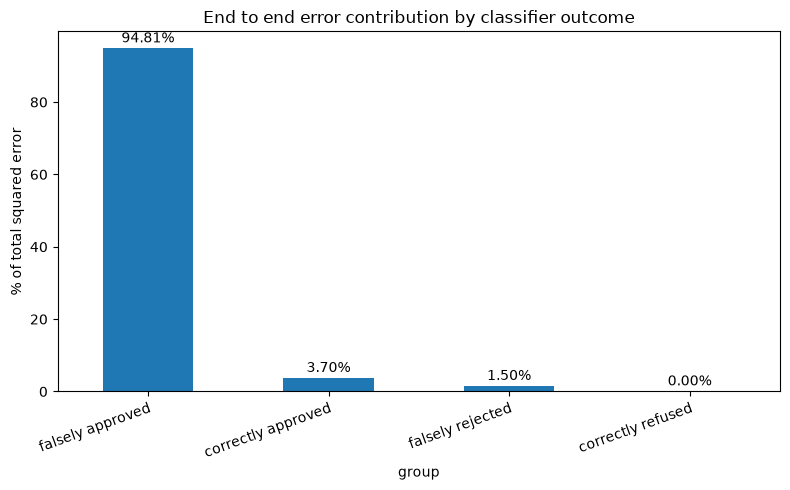

In [36]:
group = np.select(
    [
        (y_test_cls == 1) & (gate == 1),
        (y_test_cls == 0) & (gate == 0),
        (y_test_cls == 0) & (gate == 1),
        (y_test_cls == 1) & (gate == 0),
    ],
    ["correctly approved", "correctly refused", "falsely approved", "falsely rejected"],
    default="unclassified",
)
squared_error = (end_to_end - y_test_true) ** 2
total_squared_error = squared_error.sum()

decomposition = (
    pd.DataFrame({"group": group, "squared_error": squared_error})
    .groupby("group")["squared_error"]
    .agg(count="count", total_squared_error="sum")
)
decomposition["share_of_total_error_pct"] = (
    decomposition["total_squared_error"] / total_squared_error * 100
)
decomposition = decomposition.sort_values("share_of_total_error_pct", ascending=False)
print(decomposition.round(2).to_string())
print(f"\nrows covered: {int(decomposition['count'].sum()):,}   sum of shares: {decomposition['share_of_total_error_pct'].sum():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
decomposition["share_of_total_error_pct"].plot(kind="bar", ax=ax)
ax.set_ylabel("% of total squared error")
ax.set_title("End to end error contribution by classifier outcome")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=2)
plt.tight_layout()
plt.savefig("../report/figures/error_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

The 486 falsely approved rows are only 8.3 percent of the test set, yet they
account for 94.81 percent of the total squared error in the chained
prediction, confirming what this block set out to check rather than merely
assuming it. The 4,290 correctly approved rows, the bulk of the test set
that both stages get right, add just 3.70 percent, and the 2 falsely
rejected rows contribute a further 1.50 percent. The 1,087 correctly refused
rows add exactly 0, since reporting 0 for an application that is truly
refused is not a partial hit, it is exact. The fourth bar in the chart above
carries a printed 0.00% label rather than a rounded-down one, because a
prediction of 0 against a true refusal has no gap left to measure, not
because the gap is merely small enough to disappear. A handful of
misclassified rows, not the ordinary spread of regression error across
thousands of applications, decides almost the entire end to end score.

## SHAP, what each stage actually leans on

Both `best_classifier` and `best_regressor` are gradient boosting models
wrapped in a `Pipeline`, so `shap.TreeExplainer` is pointed at the fitted
tree ensemble found under `named_steps["model"]`, not at the pipeline itself,
and the features are pushed through `named_steps["pre"]` by hand first so the
explainer sees the same numeric matrix the tree was trained on rather than
the raw columns of `X_test`.

SHAP on thousands of rows through a deep boosted ensemble takes far longer
than a sample needs to, and a sample is enough to show what a model leans on
without walking every row through the explainer. At most 500 rows are used
for each stage, drawn with `random_state=RANDOM_STATE` for the same
reproducibility reason used throughout this notebook.

/Users/kushalkrishnappa/.pyenv/versions/pytorch/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


stage 1 SHAP sample: 500 of 5,865 test rows
continuous__Credit Score    1.3244
discrete__Co-Applicant      0.9495
continuous__Income (USD)    0.4657

top three combined share of total mean |SHAP|: 74.5%


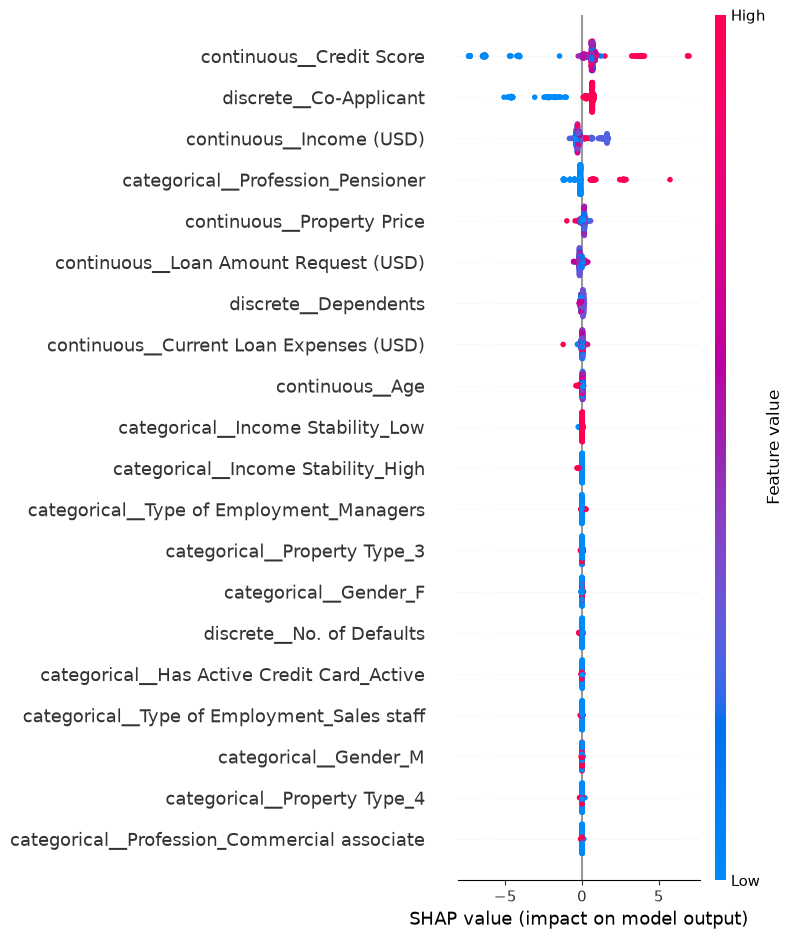

In [37]:
import shap

pre_stage1 = best_classifier.named_steps["pre"]
model_stage1 = best_classifier.named_steps["model"]
feature_names_stage1 = pre_stage1.get_feature_names_out()

sample_stage1 = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
X_shap_stage1 = pre_stage1.transform(sample_stage1)

explainer_stage1 = shap.TreeExplainer(model_stage1)
shap_values_stage1 = explainer_stage1.shap_values(X_shap_stage1)

importance_stage1 = pd.Series(
    np.abs(shap_values_stage1).mean(axis=0), index=feature_names_stage1
).sort_values(ascending=False)
print(f"stage 1 SHAP sample: {X_shap_stage1.shape[0]:,} of {len(X_test):,} test rows")
print(importance_stage1.head(3).round(4).to_string())
print(f"\ntop three combined share of total mean |SHAP|: {importance_stage1.head(3).sum() / importance_stage1.sum():.1%}")

shap.summary_plot(shap_values_stage1, X_shap_stage1, feature_names=feature_names_stage1, show=False)
plt.tight_layout()
plt.savefig("../report/figures/shap_stage1.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

The top three features by mean absolute SHAP value are `Credit Score`,
`Co-Applicant` and `Income (USD)`, together accounting for 74.5 percent of
the total SHAP magnitude across the 56 features stage 1 sees. `Credit Score`
leads with a mean absolute SHAP value of 1.3244, `Co-Applicant` follows at
0.9495 and `Income (USD)` at 0.4657. In the summary plot, a low credit score
or the absence of a co-applicant pulls a prediction toward refusal, and a
high value in either pulls it toward approval, the direction a loan
officer's intuition would already expect.

None of this says a credit score or a co-applicant causes an approval. SHAP
attributes credit to a feature for the prediction this particular model
produces on the historical decisions it was trained to match. It describes
what the model leans on, not what actually determines whether a bank
sanctions a loan.

stage 2 SHAP sample: 500 of 4,292 approved test rows
continuous__Loan Amount Request (USD)    34798.73
continuous__Credit Score                  3073.61
continuous__Property Price                 289.29

top feature alone, share of total mean |SHAP|: 90.0%
top three combined share of total mean |SHAP|: 98.7%


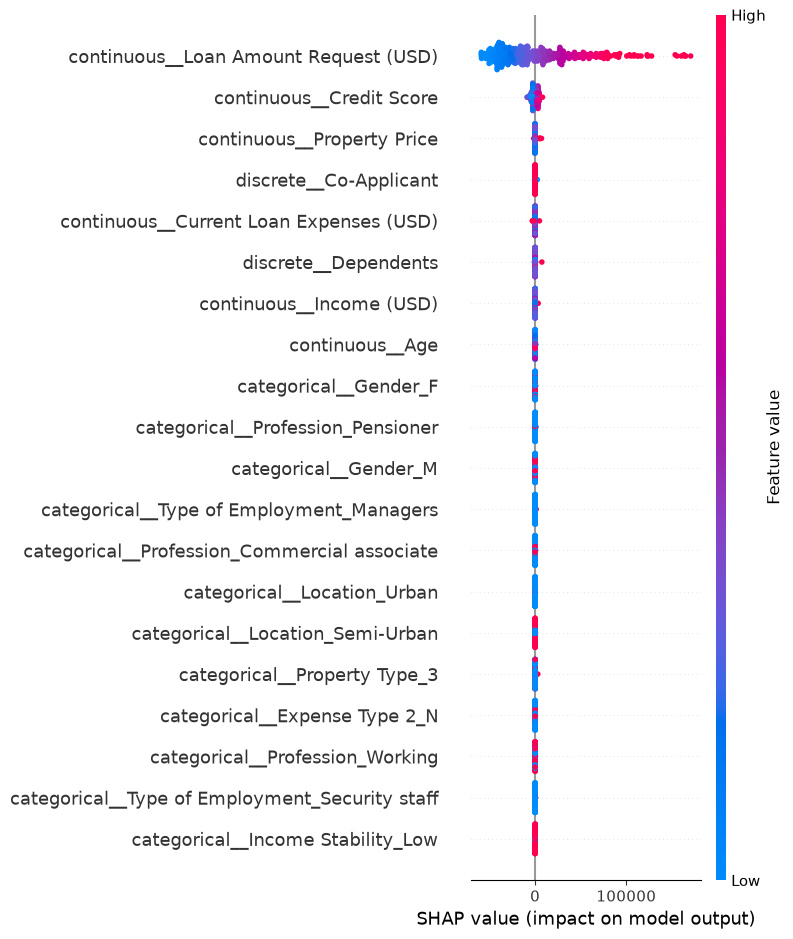

In [38]:
pre_stage2 = best_regressor.named_steps["pre"]
model_stage2 = best_regressor.named_steps["model"]
feature_names_stage2 = pre_stage2.get_feature_names_out()

sample_stage2 = X_test.loc[approved_test].sample(n=min(500, len(approved_test)), random_state=RANDOM_STATE)
X_shap_stage2 = pre_stage2.transform(sample_stage2)

explainer_stage2 = shap.TreeExplainer(model_stage2)
shap_values_stage2 = explainer_stage2.shap_values(X_shap_stage2)

importance_stage2 = pd.Series(
    np.abs(shap_values_stage2).mean(axis=0), index=feature_names_stage2
).sort_values(ascending=False)
print(f"stage 2 SHAP sample: {X_shap_stage2.shape[0]:,} of {len(approved_test):,} approved test rows")
print(importance_stage2.head(3).round(2).to_string())
print(f"\ntop feature alone, share of total mean |SHAP|: {importance_stage2.iloc[0] / importance_stage2.sum():.1%}")
print(f"top three combined share of total mean |SHAP|: {importance_stage2.head(3).sum() / importance_stage2.sum():.1%}")

shap.summary_plot(shap_values_stage2, X_shap_stage2, feature_names=feature_names_stage2, show=False)
plt.tight_layout()
plt.savefig("../report/figures/shap_stage2.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

The top three features are `Loan Amount Request (USD)`, `Credit Score` and
`Property Price`. The requested amount alone accounts for 90.0 percent of
the total SHAP magnitude across the 54 features stage 2 sees, rising to 98.7
percent once `Credit Score` and `Property Price` are added. Both figures land
on the same conclusion block 8 already reported, that 98.05 percent of the
random forest's feature importance sits on the requested amount alone, so
this plot mostly confirms that finding rather than adding a new one. The
other two features move the prediction a little further in the same
direction as the amount they are already correlated with, a higher credit
score or a higher property price nudging the sanctioned figure up, but the
scale of that nudge, a mean absolute SHAP value of 3,073.61 for credit score
and 289.29 for property price, is small next to the requested amount's
34,798.73. As with stage 1, this is what the model leans on inside its own
learned function, not a causal account of how a bank actually decides.

## Results summary

The table below is the one place in this notebook where stage 1, stage 2 and
the chained end to end result sit next to each other. Each row states plainly
which rows it was scored on, since that detail is the whole reason the end to
end row exists and the difference between it and stage 2 alone is not a
rounding matter.

In [39]:
results_summary = pd.DataFrame([
    {
        "Stage": "Stage 1, classifier",
        "Rows scored": len(X_test),
        "F1": f1_score(y_test_cls, best_classifier.predict(X_test)),
        "RMSE (USD)": np.nan,
        "MAE (USD)": np.nan,
        "R2": np.nan,
    },
    {
        "Stage": "Stage 2, regressor (approved rows only)",
        "Rows scored": len(approved_test),
        "F1": np.nan,
        "RMSE (USD)": root_mean_squared_error(y_test_amt, pred_gb),
        "MAE (USD)": mean_absolute_error(y_test_amt, pred_gb),
        "R2": r2_score(y_test_amt, pred_gb),
    },
    {
        "Stage": "End to end, predicted gate (all test rows)",
        "Rows scored": len(X_test),
        "F1": np.nan,
        "RMSE (USD)": root_mean_squared_error(y_test_true, end_to_end),
        "MAE (USD)": mean_absolute_error(y_test_true, end_to_end),
        "R2": r2_score(y_test_true, end_to_end),
    },
    {
        "Stage": "End to end, perfect gate (all test rows)",
        "Rows scored": len(X_test),
        "F1": np.nan,
        "RMSE (USD)": root_mean_squared_error(y_test_true, end_to_end_perfect),
        "MAE (USD)": mean_absolute_error(y_test_true, end_to_end_perfect),
        "R2": r2_score(y_test_true, end_to_end_perfect),
    },
])
print(results_summary.round(4).to_string(index=False))

                                     Stage  Rows scored     F1  RMSE (USD)  MAE (USD)     R2
                       Stage 1, classifier         5865 0.9462         NaN        NaN    NaN
   Stage 2, regressor (approved rows only)         4292    NaN   5137.7724  3143.8339 0.9869
End to end, predicted gate (all test rows)         5865    NaN  22814.6196  7706.5966 0.7757
  End to end, perfect gate (all test rows)         5865    NaN   4395.1197  2300.6539 0.9917


Reading down the table, stage 1's F1 of 0.9462 and stage 2's RMSE of
$5,137.77 are the two most favourable views of this system, each earned by
scoring only the rows that let that stage look its best. The bottom two rows
are the honest comparison: RMSE more than quadruples, from $5,137.77 to
$22,814.62, once the gate is the model's own predicted approval rather than
either the truth or the approved-only subset stage 2 was scored on. That gap
is the price of a stage 1 mistake, not a property of the loan amounts
themselves.

## Limitations

This project has specific weaknesses, not the generic kind that could be
attached to any modelling exercise. They are recorded here rather than left
implicit.

**The dataset itself is not fully trustworthy.** It is a Kaggle extract with
no documented provenance, no description of how the 30,000 applications were
collected or which institution's decisions they record. Block 2 already found
that `Property Age` is not an age at all, it is an exact copy of
`Income (USD)` down to the cent, a column that was labelled and shipped as
something it is not. One confirmed error of that kind, found only because it
happened to be checked, is reason to treat the rest of the file as unverified
rather than assume the remaining columns are clean.

**Stage 2 is close to a one-feature problem.** Block 8 found that
`Loan Amount Request (USD)` alone, with a plain linear regression and nothing
else, reaches an RMSE of $6,123.84 and an R2 of 0.9814, fractionally better
than the 54-feature linear regression's own $6,339.64 and 0.9800. The tuned
gradient boosting model used as `best_regressor` scores higher still, but the
high R2 in this stage is a property of how tightly the sanctioned amount is
anchored to the requested one, not evidence that the model has learned
anything resembling how a bank underwrites a loan.

**Stage 1 is where the real difficulty sits, and it leans toward approval.**
`best_classifier` produced 486 false approvals against only 2 false
rejections on the test set. For an applicant, that asymmetry means a genuine
refusal is, far more often than not, mistakenly reported as an approval with
a specific dollar figure attached to it, an applicant told a number is coming
when it never will, and almost never the reverse. Trusting this model's
output at face value is safer for someone who is actually approved than for
someone who is actually refused.

**The neural network overfits and nothing in this project corrects for it.**
Block 8's training run shows validation loss reaching its lowest point at
epoch 25 before climbing back up through epoch 50 while training loss keeps
falling, and the network is still scored at epoch 50 regardless, since no
early stopping and no checkpoint selection were built into that training
loop.

**No fairness audit was carried out, even though `Gender` is one of the
features handed to both stages.** The target this project learns to predict
is a historical lending decision, and any bias already present in how those
loans were sanctioned is reproduced rather than corrected by a model trained
to match it. Nothing in this notebook checks whether refusal rates or
sanctioned amounts differ by gender once the other columns are held fixed.

**The model reflects one snapshot of lending behaviour.** It is fitted once
on a fixed file and never revisited. If the lending conditions that produced
these 29,322 applications shift, through interest rates, underwriting rules
or the mix of applicants, this model has no mechanism to notice and would
need to be retrained on newer data to stay accurate.